# Modelado Yelp: regresión y clasificación

Esta notebook reúne de forma ordenada el trabajo de modelado realizado sobre el dataset de Yelp, separando por modelo y dejando claro qué objetivo, qué métricas se usan y cómo interpretar los resultados.

Se estructura en dos grandes bloques:
- Regresión: predicción del volumen de check-ins (`n_checkins`)
- Clasificación: predicción de usuario elite vs no elite (`elite_encoded`)

# Justificación de los motivos para el modelado

Para el departamento de marketing de una marca no tan grande, resulta útil identificar y captar embajadores de la marca antes que se conviertan en personalidades muy populares, ya que una vez que llegan a ése status, pueden ser tentados por marcas muy grandes.

¿Tiene sentido como problema de ML?
* Para entrenar un modelo necesitamos una cantidad suficiente de datos.
    * Utilizamos el dataset de Yelp de usuarios (cientas de miles de observaciones) y tratamos de predecir usuarios candidatos al status "elite" (potenciales embajadores de marca)
* Los datos deben estar disponibles o ser posibles de recolectar.
    * Disponible en Keggle
* La calidad de los datos suele ser más importante que el algoritmo.
    * Se dispone de mas observaciones de las que es prtáctico procesar

In [97]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from scipy.stats import pointbiserialr

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Python executable:', sys.executable)
print('Optuna version:', optuna.__version__)


def find_datasets_dir(folder_name: str = 'datasets') -> Path:
    start = Path.cwd()
    candidates = []

    # Búsqueda directa desde la ubicación actual y sus padres
    for d in (start, *start.parents):
        candidates.append(d / folder_name)
        candidates.append(d / 'yelp_dataset' / folder_name)

    # Búsqueda adicional por el árbol de trabajo del proyecto
    candidates.extend([
        start / 'yelp_dataset' / folder_name,
        start.parent / 'yelp_dataset' / folder_name,
    ])

    for candidate in candidates:
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError(
        f"No se encontró la carpeta '{folder_name}' desde {start}. "
        "Se esperaba en 'yelp_dataset/datasets'."
    )


def read_json_sample(path, nrows=100_000):
    return pd.read_json(path, lines=True, nrows=nrows)


def drop_if_exists(df, columns):
    existing = [col for col in columns if col in df.columns]
    return df.drop(columns=existing)


BASE_PATH = find_datasets_dir()
SAMPLE_ROWS = 100_000
print(f'Datasets encontrados en: {BASE_PATH}')
print(f'Versión resumida trabajando con una muestra de hasta {SAMPLE_ROWS:,} filas por archivo grande.')

Python executable: c:\Users\Leoes\.conda\envs\tp\python.exe
Optuna version: 4.6.0
Datasets encontrados en: c:\CEIA\B2\ML\datasets
Versión resumida trabajando con una muestra de hasta 100,000 filas por archivo grande.


In [98]:
print('Cargando datasets (muestra resumida)...')

df_user = read_json_sample(BASE_PATH / 'yelp_academic_dataset_user.json', nrows=SAMPLE_ROWS)
df_review = read_json_sample(BASE_PATH / 'yelp_academic_dataset_review.json', nrows=SAMPLE_ROWS)
df_tip = read_json_sample(BASE_PATH / 'yelp_academic_dataset_tip.json', nrows=SAMPLE_ROWS)
df_business = read_json_sample(BASE_PATH / 'yelp_academic_dataset_business.json', nrows=SAMPLE_ROWS)
df_checkin = read_json_sample(BASE_PATH / 'yelp_academic_dataset_checkin.json', nrows=SAMPLE_ROWS)
df_checkin['n_checkins'] = df_checkin['date'].fillna('').apply(lambda x: 0 if not str(x).strip() else str(x).count(',') + 1)

print('Carga finalizada.')

# Resumen rápido de los datasets
summary_datasets = pd.DataFrame({
    'Dataset': ['Users', 'Reviews', 'Tips', 'Check-ins', 'Business'],
    'Filas': [len(df_user), len(df_review), len(df_tip), len(df_checkin), len(df_business)],
    'Columnas': [df_user.shape[1], df_review.shape[1], df_tip.shape[1], df_checkin.shape[1], df_business.shape[1]],
    'NaN totales': [int(df_user.isna().sum().sum()), int(df_review.isna().sum().sum()), int(df_tip.isna().sum().sum()), int(df_checkin.isna().sum().sum()), int(df_business.isna().sum().sum())],
})

display(summary_datasets)

Cargando datasets (muestra resumida)...
Carga finalizada.


,Dataset,Filas,Columnas,NaN totales
0,Users,100000,22,0
1,Reviews,100000,9,0
2,Tips,100000,5,0
3,Check-ins,100000,3,0
4,Business,100000,14,24590


## 0) Análisis exploratorio de datos (EDA)

### 0.1 Dataset de Usuarios (`df_user`)

#### Estructura general

In [99]:
print(f"Dimensiones: {df_user.shape[0]:,} filas x {df_user.shape[1]} columnas\n")
print("Tipos de datos:")
print(df_user.dtypes.to_string())


Dimensiones: 100,000 filas x 22 columnas

Tipos de datos:
user_id                   str
name                      str
review_count            int64
yelping_since             str
useful                  int64
funny                   int64
cool                    int64
elite                     str
friends                   str
fans                    int64
average_stars         float64
compliment_hot          int64
compliment_more         int64
compliment_profile      int64
compliment_cute         int64
compliment_list         int64
compliment_note         int64
compliment_plain        int64
compliment_cool         int64
compliment_funny        int64
compliment_writer       int64
compliment_photos       int64


#### Muestra de registros

In [100]:
df_user.head(3)


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,3.9100,250,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,3.7400,1145,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,3.3200,89,13,10,17,3,66,96,119,119,35,18


#### Variables derivadas

Se calculan las mismas variables derivadas que en `yelp_dataset_description_modify.ipynb` (antigüedad, cantidad de amigos, años como elite y total de compliments). Estas columnas se reutilizan más adelante en la sección de clasificación, por lo que quedan disponibles en `df_user` desde el EDA.

In [101]:
# La columna raw `elite` contiene los anios en los que el usuario fue elite; un valor no vacio indica clase positiva.
df_user['is_elite'] = df_user['elite'].fillna('').astype(str).str.strip().ne('').astype(int)
df_user['yelping_since'] = pd.to_datetime(df_user['yelping_since'])
df_user['years_active'] = (pd.Timestamp('2026-05-31') - df_user['yelping_since']).dt.days / 365.25
df_user['friend_count'] = df_user['friends'].apply(lambda x: 0 if (x == 'None' or x == '') else len(str(x).split(',')))
df_user['elite_years'] = df_user['elite'].fillna('').astype(str).str.strip().str.split(',').apply(lambda xs: len([x for x in xs if x and x != 'None']))

compliment_cols = [c for c in df_user.columns if c.startswith('compliment_')]
df_user['total_compliments'] = df_user[compliment_cols].sum(axis=1)


#### Estadísticas descriptivas

In [102]:
df_user.describe(include=[np.number])


,review_count,useful,funny,cool,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,is_elite,years_active,friend_count,elite_years,total_compliments
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,92.6335,217.2179,91.4065,131.0987,7.4790,3.8532,9.2012,1.5262,0.9880,0.6765,0.3995,7.3501,16.3976,14.6798,14.6798,5.9972,5.1302,0.1986,14.0661,126.0780,0.9336,77.0261
std,235.3433,1635.7318,1058.0499,1401.4377,57.4931,0.6814,123.1970,21.7286,31.4984,12.5540,12.5386,69.7608,237.1286,172.5641,172.5641,70.3205,104.6430,0.3990,2.5166,272.8897,2.3471,920.9843
min,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6.8583,1.0000,0.0000,0.0000
25%,10.0000,7.0000,1.0000,1.0000,0.0000,3.5300,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,12.2957,12.0000,0.0000,0.0000
50%,27.0000,26.0000,5.0000,7.0000,1.0000,3.9100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,14.2149,51.0000,0.0000,3.0000
75%,80.0000,96.0000,24.0000,31.0000,4.0000,4.2800,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3.0000,2.0000,2.0000,1.0000,0.0000,0.0000,15.8084,147.0000,0.0000,13.0000
max,17473.0000,206296.0000,185823.0000,195814.0000,12497.0000,5.0000,12391.0000,4347.0000,7039.0000,1744.0000,2607.0000,8616.0000,28974.0000,13280.0000,13280.0000,9821.0000,14045.0000,1.0000,21.6235,14995.0000,17.0000,82084.0000


#### Métricas clave

In [103]:
user_summary = pd.DataFrame({
    'Metrica': [
        'Total de usuarios',
        'Antiguedad media (anios)',
        'Reviews por usuario (media)',
        'Fans por usuario (media)',
        'Amigos por usuario (media)',
        '% usuarios elite (alguna vez)',
        'Estrellas promedio (media)',
    ],
    'Valor': [
        f"{len(df_user):,}",
        f"{df_user['years_active'].mean():.2f}",
        f"{df_user['review_count'].mean():.2f}",
        f"{df_user['fans'].mean():.2f}",
        f"{df_user['friend_count'].mean():.2f}",
        f"{(df_user['elite_years'] > 0).mean() * 100:.2f} %",
        f"{df_user['average_stars'].mean():.4f}",
    ]
})
display(user_summary)


,Metrica,Valor
0,Total de usuarios,"100,000"
1,Antiguedad media (anios),14.07
2,Reviews por usuario (media),92.63
3,Fans por usuario (media),7.48
4,Amigos por usuario (media),126.08
5,% usuarios elite (alguna vez),19.86 %
6,Estrellas promedio (media),3.8532


#### Distribuciones principales

Las variables de actividad (`review_count`, `fans`, `friend_count`) están muy sesgadas hacia la derecha, por lo que se grafican en escala log1p. Se marcan moda, media y mediana para comparar la forma de cada distribución.

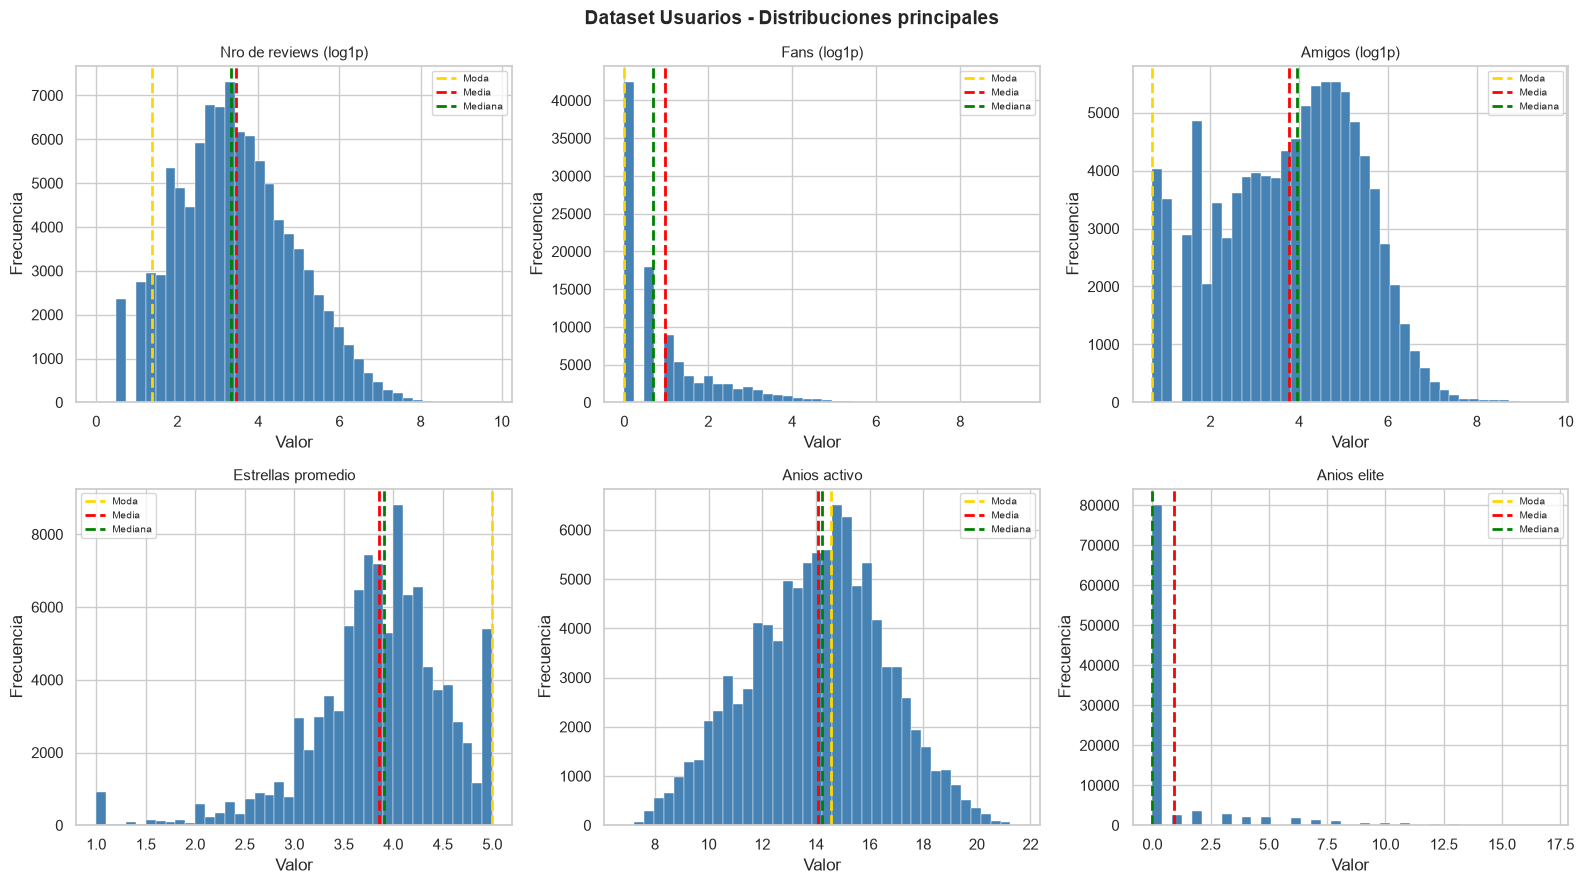

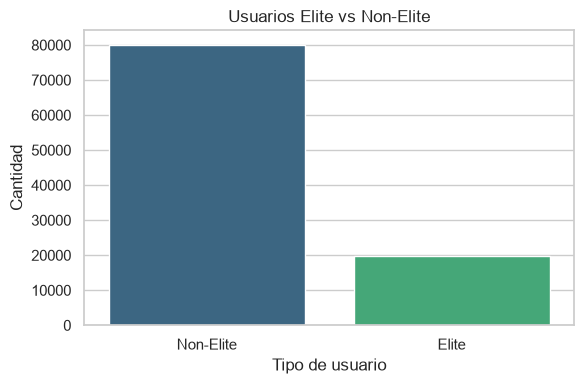

In [104]:
cols_dist = [
    ('review_count', 'Nro de reviews', True),
    ('fans', 'Fans', True),
    ('friend_count', 'Amigos', True),
    ('average_stars', 'Estrellas promedio', False),
    ('years_active', 'Anios activo', False),
    ('elite_years', 'Anios elite', False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Usuarios - Distribuciones principales', fontsize=14, fontweight='bold')

for ax, (col, label, do_log) in zip(axes.flat, cols_dist):
    data = df_user[col].dropna()
    if do_log:
        data = np.log1p(data)
        label += ' (log1p)'
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(data.mode()[0], color='gold', ls='--', lw=2, label='Moda')
    ax.axvline(data.mean(), color='red', ls='--', lw=2, label='Media')
    ax.axvline(data.median(), color='green', ls='--', lw=2, label='Mediana')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
elite_counts = df_user['elite'].apply(lambda x: 'Elite' if isinstance(x, str) and x.strip() not in ('', 'None') else 'Non-Elite').value_counts()
sns.barplot(x=elite_counts.index, y=elite_counts.values, hue=elite_counts.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Usuarios Elite vs Non-Elite')
ax.set_xlabel('Tipo de usuario')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()


#### Cuartiles de variables numéricas

,Q1 (25%),Mediana (50%),Q3 (75%)
Variable,,,
review_count,10.00,27.00,80.00
useful,7.00,26.00,96.00
funny,1.00,5.00,24.00
cool,1.00,7.00,31.00
fans,0.00,1.00,4.00
average_stars,3.53,3.91,4.28
years_active,12.30,14.21,15.81
friend_count,12.00,51.00,147.00
elite_years,0.00,0.00,0.00


C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\964422523.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_user[col].dropna(), vert=True, patch_artist=True,
C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\964422523.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_user[col].dropna(), vert=True, patch_artist=True,
C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\964422523.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_user[col].dropna(), vert=True, patch_artist=True,
C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\964422523.py:13: MatplotlibDeprecationWarning: vert: bool was dep

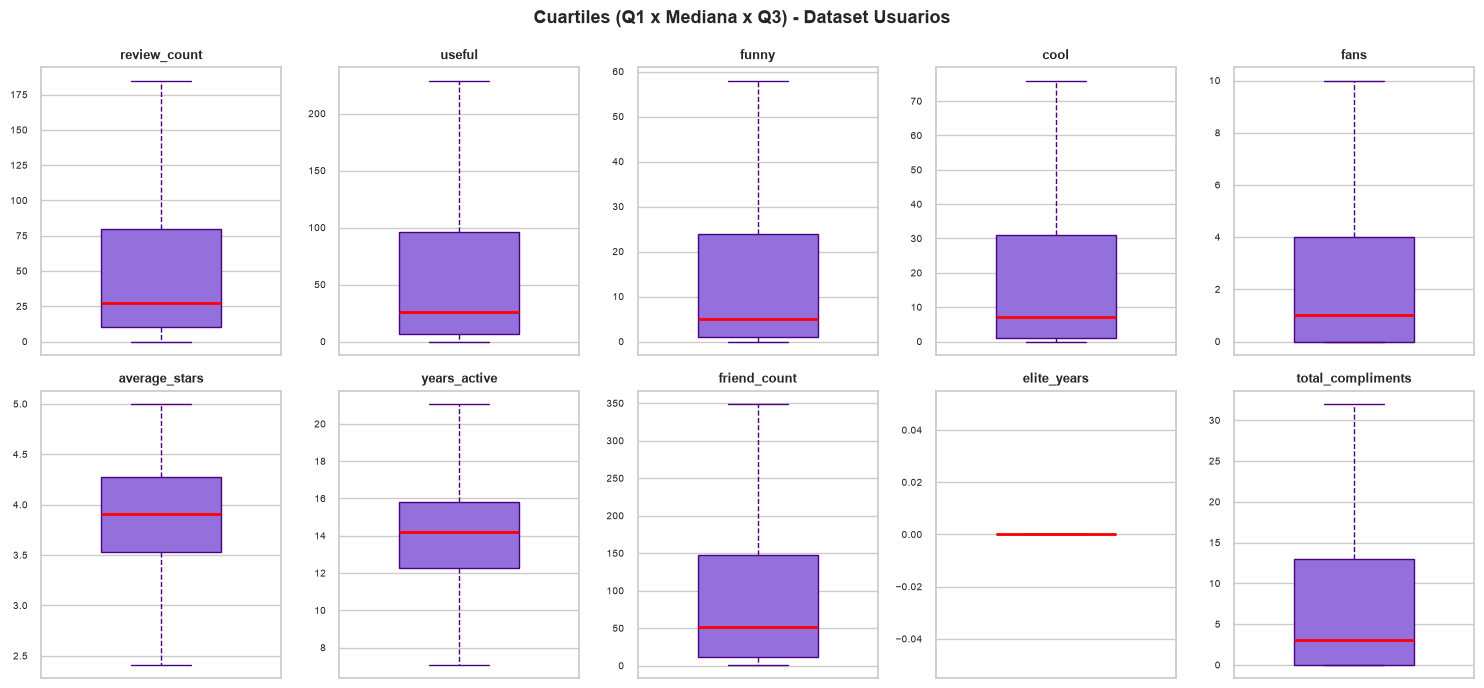

In [105]:
cols_q = ['review_count', 'useful', 'funny', 'cool', 'fans',
          'average_stars', 'years_active', 'friend_count', 'elite_years', 'total_compliments']

qt = df_user[cols_q].quantile([0.25, 0.50, 0.75]).T
qt.columns = ['Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)']
qt.index.name = 'Variable'
display(qt.style.format('{:,.2f}').set_caption('Cuartiles - Dataset Usuarios'))

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(cols_q):
    axes[i].boxplot(df_user[col].dropna(), vert=True, patch_artist=True,
                     showfliers=False,
                     boxprops=dict(facecolor='mediumpurple', color='#4B0082'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='#4B0082', linestyle='--'),
                     capprops=dict(color='#4B0082'),
                     widths=0.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].tick_params(axis='y', labelsize=7)

fig.suptitle('Cuartiles (Q1 x Mediana x Q3) - Dataset Usuarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 0.2 Dataset de Reviews (`df_review`)

#### Estructura general

In [106]:
print(f"Dimensiones: {df_review.shape[0]:,} filas x {df_review.shape[1]} columnas\n")
print("Tipos de datos:")
print(df_review.dtypes.to_string())


Dimensiones: 100,000 filas x 9 columnas

Tipos de datos:
review_id                 str
user_id                   str
business_id               str
stars                   int64
useful                  int64
funny                   int64
cool                    int64
text                      str
date           datetime64[us]


#### Muestra de registros

In [107]:
df_review.head(3)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30


#### Estadísticas descriptivas

In [108]:
df_review.describe(include=[np.number])


,stars,useful,funny,cool
count,100000.0000,100000.0000,100000.0000,100000.0000
mean,3.8429,0.8990,0.2572,0.3470
std,1.3547,2.2052,1.0102,1.0664
min,1.0000,0.0000,0.0000,0.0000
25%,3.0000,0.0000,0.0000,0.0000
50%,4.0000,0.0000,0.0000,0.0000
75%,5.0000,1.0000,0.0000,0.0000
max,5.0000,320.0000,98.0000,49.0000


#### Métricas clave

In [109]:
df_review['text_len'] = df_review['text'].str.len()

review_summary = pd.DataFrame({
    'Metrica': [
        'Total de reviews',
        'Negocios unicos',
        'Usuarios unicos',
        'Estrellas promedio',
        'Texto promedio (caracteres)',
        'Useful promedio',
        'Funny promedio',
        'Cool promedio',
    ],
    'Valor': [
        f"{len(df_review):,}",
        f"{df_review['business_id'].nunique():,}",
        f"{df_review['user_id'].nunique():,}",
        f"{df_review['stars'].mean():.4f}",
        f"{df_review['text_len'].mean():.1f}",
        f"{df_review['useful'].mean():.2f}",
        f"{df_review['funny'].mean():.2f}",
        f"{df_review['cool'].mean():.2f}",
    ]
})
display(review_summary)


,Metrica,Valor
0,Total de reviews,"100,000"
1,Negocios unicos,"9,973"
2,Usuarios unicos,"79,345"
3,Estrellas promedio,3.8429
4,Texto promedio (caracteres),548.4
5,Useful promedio,0.90
6,Funny promedio,0.26
7,Cool promedio,0.35


#### Distribuciones principales

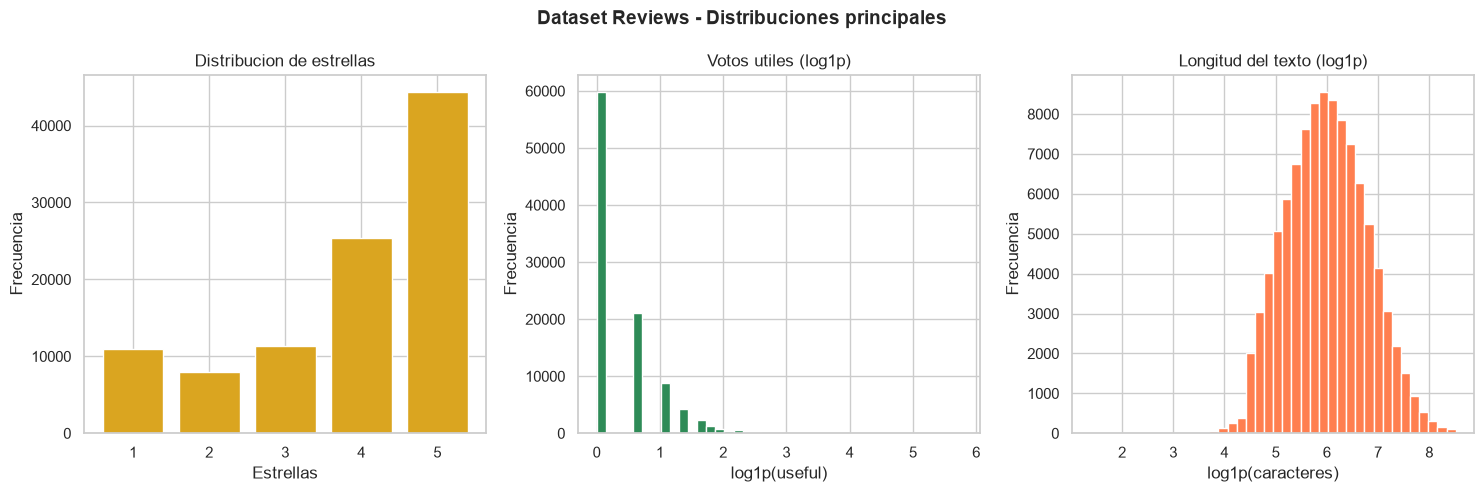

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dataset Reviews - Distribuciones principales', fontsize=14, fontweight='bold')

star_counts = df_review['stars'].value_counts().sort_index()
axes[0].bar(star_counts.index, star_counts.values, color='goldenrod', edgecolor='white')
axes[0].set_title('Distribucion de estrellas')
axes[0].set_xlabel('Estrellas')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df_review['useful'].clip(lower=0)), bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('Votos utiles (log1p)')
axes[1].set_xlabel('log1p(useful)')
axes[1].set_ylabel('Frecuencia')

axes[2].hist(np.log1p(df_review['text_len'].dropna()), bins=40, color='coral', edgecolor='white')
axes[2].set_title('Longitud del texto (log1p)')
axes[2].set_xlabel('log1p(caracteres)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


#### Cuartiles de variables numéricas

,Q1 (25%),Mediana (50%),Q3 (75%)
Variable,,,
stars,3.00,4.00,5.00
useful,0.00,0.00,1.00
funny,0.00,0.00,0.00
cool,0.00,0.00,0.00
text_len,226.00,395.00,693.00


C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\4198080658.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_review[col].dropna(), vert=True, patch_artist=True,
C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\4198080658.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_review[col].dropna(), vert=True, patch_artist=True,
C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\4198080658.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_review[col].dropna(), vert=True, patch_artist=True,
C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\4198080658.py:11: MatplotlibDeprecationWarning: vert: bo

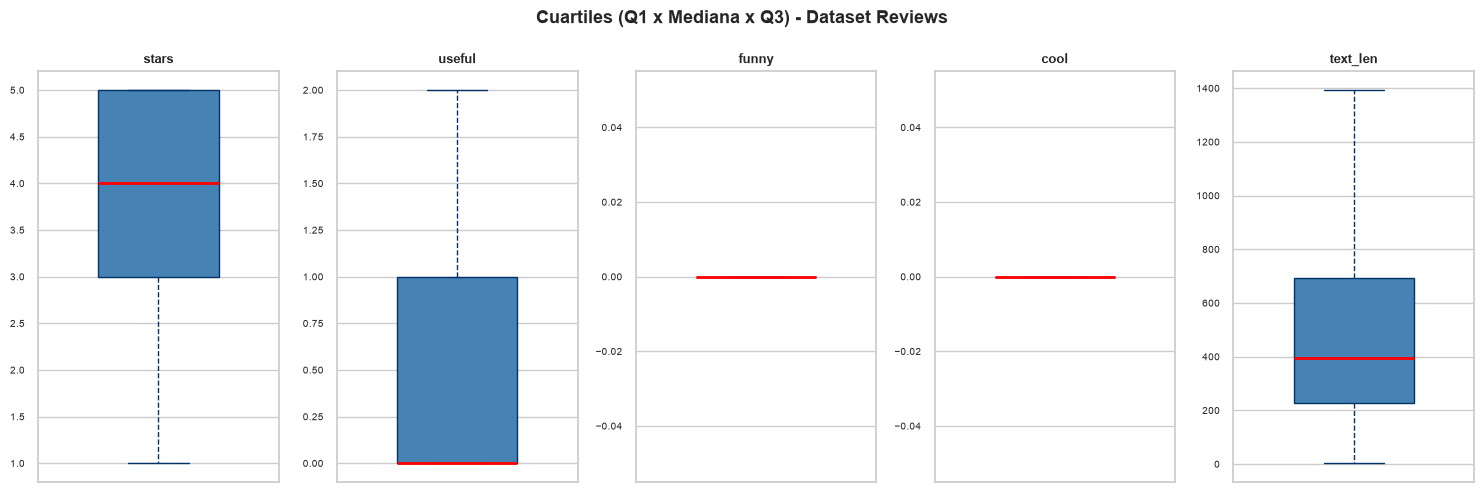

In [111]:
cols_q = ['stars', 'useful', 'funny', 'cool', 'text_len']

qt = df_review[cols_q].quantile([0.25, 0.50, 0.75]).T
qt.columns = ['Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)']
qt.index.name = 'Variable'
display(qt.style.format('{:,.2f}').set_caption('Cuartiles - Dataset Reviews'))

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, col in enumerate(cols_q):
    axes[i].boxplot(df_review[col].dropna(), vert=True, patch_artist=True,
                     showfliers=False,
                     boxprops=dict(facecolor='steelblue', color='#003366'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='#003366', linestyle='--'),
                     capprops=dict(color='#003366'),
                     widths=0.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].tick_params(axis='y', labelsize=7)

fig.suptitle('Cuartiles (Q1 x Mediana x Q3) - Dataset Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 0.3 Dataset de Negocios (`df_business`)

#### Estructura general

In [112]:
print(f"Dimensiones: {df_business.shape[0]:,} filas x {df_business.shape[1]} columnas\n")
print("Tipos de datos:")
print(df_business.dtypes.to_string())


Dimensiones: 100,000 filas x 14 columnas

Tipos de datos:
business_id         str
name                str
address             str
city                str
state               str
postal_code         str
latitude        float64
longitude       float64
stars           float64
review_count      int64
is_open           int64
attributes       object
categories          str
hours            object


#### Muestra de registros

In [113]:
df_business.head(3)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.4267,-119.7112,5.0000,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.5511,-90.3357,3.0000,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.2232,-110.8805,3.5000,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."


#### Estadísticas descriptivas

In [114]:
df_business.describe(include=[np.number])


,latitude,longitude,stars,review_count,is_open
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,36.6674,-89.3780,3.5972,44.7974,0.7962
std,5.8739,14.9166,0.9742,115.3319,0.4028
min,27.5551,-120.0951,1.0000,5.0000,0.0000
25%,32.1868,-90.3585,3.0000,8.0000,1.0000
50%,38.7735,-86.1226,3.5000,15.0000,1.0000
75%,39.9541,-75.4250,4.5000,37.0000,1.0000
max,53.6792,-74.6586,5.0000,6093.0000,1.0000


#### Métricas clave

In [115]:
business_summary = pd.DataFrame({
    'Metrica': [
        'Total de negocios',
        'Estados unicos',
        'Ciudades unicas',
        'Estrellas promedio',
        'Negocios abiertos (%)',
        'Categorias faltantes',
    ],
    'Valor': [
        f"{len(df_business):,}",
        f"{df_business['state'].nunique():,}",
        f"{df_business['city'].nunique():,}",
        f"{df_business['stars'].mean():.4f}",
        f"{df_business['is_open'].mean() * 100:.2f} %",
        f"{int(df_business['categories'].isna().sum()):,}",
    ]
})
display(business_summary)


,Metrica,Valor
0,Total de negocios,"100,000"
1,Estados unicos,24
2,Ciudades unicas,"1,207"
3,Estrellas promedio,3.5972
4,Negocios abiertos (%),79.62 %
5,Categorias faltantes,69


#### Distribuciones principales

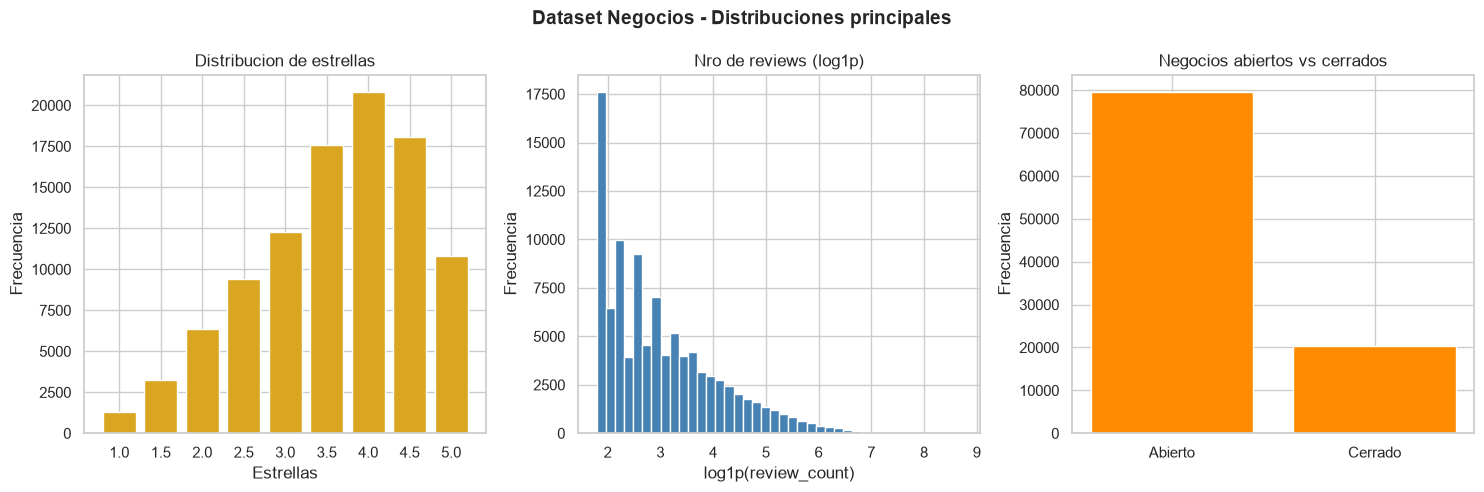

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dataset Negocios - Distribuciones principales', fontsize=14, fontweight='bold')

star_counts = df_business['stars'].value_counts().sort_index()
axes[0].bar(star_counts.index.astype(str), star_counts.values, color='goldenrod', edgecolor='white')
axes[0].set_title('Distribucion de estrellas')
axes[0].set_xlabel('Estrellas')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df_business['review_count']), bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Nro de reviews (log1p)')
axes[1].set_xlabel('log1p(review_count)')
axes[1].set_ylabel('Frecuencia')

open_counts = df_business['is_open'].map({1: 'Abierto', 0: 'Cerrado'}).value_counts()
axes[2].bar(open_counts.index, open_counts.values, color='darkorange', edgecolor='white')
axes[2].set_title('Negocios abiertos vs cerrados')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


#### Cuartiles de variables numéricas

,Q1 (25%),Mediana (50%),Q3 (75%)
Variable,,,
stars,3.00,3.50,4.50
review_count,8.00,15.00,37.00


C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\76212353.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_business[col].dropna(), vert=True, patch_artist=True,
C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\76212353.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_business[col].dropna(), vert=True, patch_artist=True,


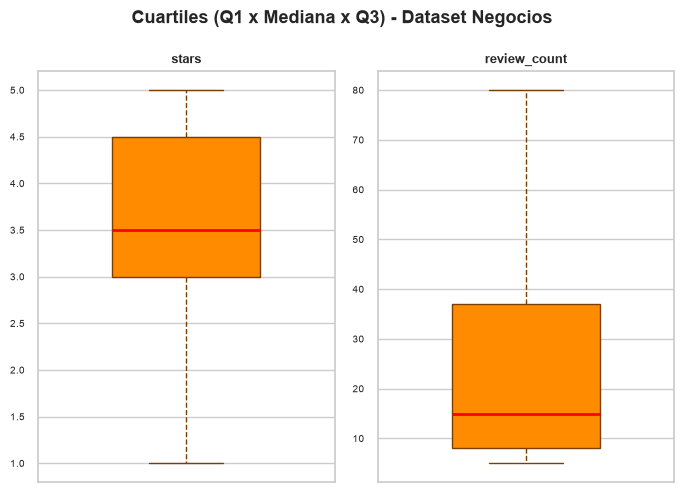

In [117]:
cols_q = ['stars', 'review_count']

qt = df_business[cols_q].quantile([0.25, 0.50, 0.75]).T
qt.columns = ['Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)']
qt.index.name = 'Variable'
display(qt.style.format('{:,.2f}').set_caption('Cuartiles - Dataset Negocios'))

fig, axes = plt.subplots(1, 2, figsize=(7, 5))

for i, col in enumerate(cols_q):
    axes[i].boxplot(df_business[col].dropna(), vert=True, patch_artist=True,
                     showfliers=False,
                     boxprops=dict(facecolor='darkorange', color='#7A3E00'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='#7A3E00', linestyle='--'),
                     capprops=dict(color='#7A3E00'),
                     widths=0.5)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].tick_params(axis='y', labelsize=7)

fig.suptitle('Cuartiles (Q1 x Mediana x Q3) - Dataset Negocios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 0.4 Dataset de Check-ins (`df_checkin`)

#### Estructura general

In [118]:
print(f"Dimensiones: {df_checkin.shape[0]:,} filas x {df_checkin.shape[1]} columnas\n")
print("Tipos de datos:")
print(df_checkin.dtypes.to_string())


Dimensiones: 100,000 filas x 3 columnas

Tipos de datos:
business_id      str
date             str
n_checkins     int64


#### Muestra de registros

In [119]:
df_checkin.head(3)


,business_id,date,n_checkins
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020...",11
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011...",10
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22",2


#### Estadísticas descriptivas

In [120]:
df_checkin[['n_checkins']].describe()


,n_checkins
count,100000.0000
mean,102.4436
std,444.7914
min,1.0000
25%,6.0000
50%,20.0000
75%,71.0000
max,52144.0000


#### Métricas clave

In [121]:
checkins_per_business = df_checkin.set_index('business_id')['n_checkins']

checkin_summary = pd.DataFrame({
    'Metrica': [
        'Total de negocios con check-ins',
        'Check-ins totales',
        'Check-ins por negocio (media)',
        'Check-ins por negocio (mediana)',
    ],
    'Valor': [
        f"{len(df_checkin):,}",
        f"{checkins_per_business.sum():,}",
        f"{checkins_per_business.mean():.2f}",
        f"{checkins_per_business.median():.2f}",
    ]
})
display(checkin_summary)


,Metrica,Valor
0,Total de negocios con check-ins,"100,000"
1,Check-ins totales,"10,244,361"
2,Check-ins por negocio (media),102.44
3,Check-ins por negocio (mediana),20.00


#### Distribuciones principales

Al igual que `review_count` y `fans` en el dataset de usuarios, `n_checkins` está muy sesgada a la derecha (pocos negocios concentran muchísimos check-ins), por lo que se visualiza en escala log1p.

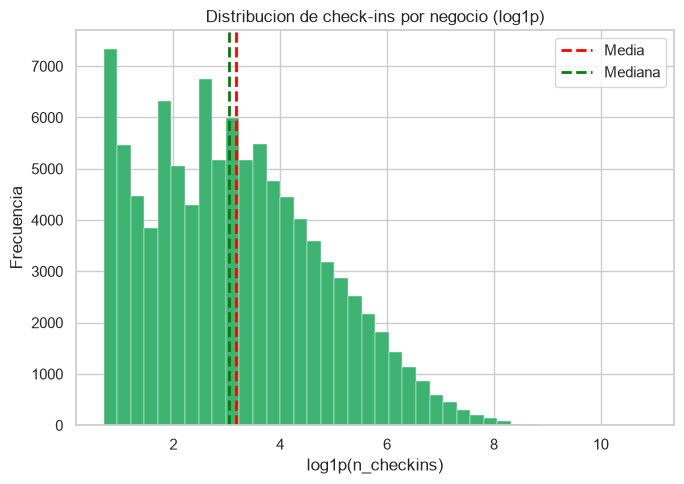

In [122]:
data = np.log1p(df_checkin['n_checkins'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(data, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax.axvline(data.mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(data.median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Distribucion de check-ins por negocio (log1p)')
ax.set_xlabel('log1p(n_checkins)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()


#### Cuartiles

,Q1 (25%),Mediana (50%),Q3 (75%)
Variable,,,
n_checkins,6.00,20.00,71.00


C:\Users\Leoes\AppData\Local\Temp\ipykernel_29660\2417967484.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df_checkin['n_checkins'].dropna(), vert=True, patch_artist=True,


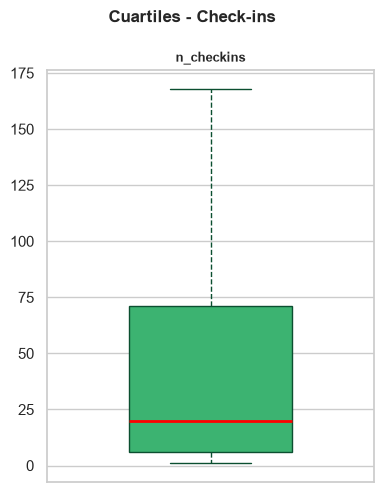

In [123]:
qt = df_checkin[['n_checkins']].quantile([0.25, 0.50, 0.75]).T
qt.columns = ['Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)']
qt.index.name = 'Variable'
display(qt.style.format('{:,.2f}').set_caption('Cuartiles - Check-ins por negocio'))

fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(df_checkin['n_checkins'].dropna(), vert=True, patch_artist=True,
           showfliers=False,
           boxprops=dict(facecolor='mediumseagreen', color='#0B4F30'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='#0B4F30', linestyle='--'),
           capprops=dict(color='#0B4F30'),
           widths=0.5)
ax.set_title('n_checkins', fontsize=9, fontweight='bold')
ax.set_xticks([])
fig.suptitle('Cuartiles - Check-ins', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 1) Regresión: predicción de `n_checkins`

El objetivo es predecir la cantidad de visitas de un negocio. Para reducir la asimetría de la distribución se trabaja con la transformación `log1p`, y luego se vuelve a la escala original con `expm1` para calcular métricas interpretables.

In [124]:
# Preparación del dataset de regresión

# Se agregan variables útiles para modelado
biz = df_business[['business_id', 'stars', 'review_count', 'state', 'city', 'is_open', 'attributes', 'hours']].copy()
biz = biz.set_index('business_id').join(df_checkin.set_index('business_id')['date'].fillna('').apply(lambda x: 0 if not str(x).strip() else str(x).count(',') + 1).rename('n_checkins'), how='inner')


def n_attributes(attr):
    if isinstance(attr, dict):
        return len(attr)
    return 0


def n_days_open(hours):
    if isinstance(hours, dict):
        return sum(1 for v in hours.values() if v and str(v).strip() != '0:0-0:0')
    return 0


biz['n_attributes'] = biz['attributes'].apply(n_attributes)
biz['n_days_open'] = biz['hours'].apply(n_days_open)

le_state = LabelEncoder()
biz['state_enc'] = le_state.fit_transform(biz['state'].fillna('Unknown'))
city_freq = biz['city'].value_counts()
biz['city_freq'] = biz['city'].map(city_freq).fillna(1)

feature_cols = ['stars', 'review_count', 'is_open', 'n_attributes', 'n_days_open', 'state_enc', 'city_freq']
X = biz[feature_cols].fillna(0).astype(float)
y_log = np.log1p(biz['n_checkins'])
y_raw = biz['n_checkins']

print(f'Features: {feature_cols}')
print(f'Target n_checkins: media={y_raw.mean():.1f} | mediana={y_raw.median():.1f} | max={y_raw.max():,}')
print(f'log1p(n_checkins): media={y_log.mean():.3f} | std={y_log.std():.3f} | skew={y_log.skew():.3f}')

Features: ['stars', 'review_count', 'is_open', 'n_attributes', 'n_days_open', 'state_enc', 'city_freq']
Target n_checkins: media=104.8 | mediana=20.0 | max=52,144
log1p(n_checkins): media=3.182 | std=1.625 | skew=0.446


### Modelo 1: regresión lineal

La regresión lineal sirve como baseline interpretativo. Es el punto de comparación más sencillo y permite entender la relación lineal entre las variables predictoras y la cantidad esperada de check-ins.

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test_raw = np.expm1(y_test)

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_log = lr.predict(X_test)
pred_raw = np.expm1(pred_log)

lr_metrics = {
    'MAE (log)': mean_absolute_error(y_test, pred_log),
    'RMSE (log)': np.sqrt(mean_squared_error(y_test, pred_log)),
    'R² (log)': r2_score(y_test, pred_log),
    'MAE (orig)': mean_absolute_error(y_test_raw, pred_raw),
    'RMSE (orig)': np.sqrt(mean_squared_error(y_test_raw, pred_raw)),
}

print('Métricas de regresión lineal:')
for k, v in lr_metrics.items():
    print(f'{k}: {v:.4f}')

Métricas de regresión lineal:
MAE (log): 0.9747
RMSE (log): 1.2360
R² (log): 0.4180
MAE (orig): 12739369.8736
RMSE (orig): 1207100916.8338


#### Métricas características de la regresión lineal

- MAE (log): error medio absoluto en la escala transformada
- RMSE (log): penaliza más los errores grandes
- R² (log): proporción de varianza explicada
- MAE (orig): error absoluto sobre escala original
- RMSE (orig): error cuadrático medio sobre escala original

La regresión lineal es útil como baseline, pero no captura relaciones no lineales que podrían existir entre la popularidad del negocio y sus atributos.

### Modelo 2: random forest regressor

El random forest es un modelo no lineal que suele tener mejor capacidad de capturar interacciones complejas entre variables y suele mejorar el baseline lineal.

Métricas de Random Forest regressor:
MAE (log): 0.7697
RMSE (log): 0.9831
R² (log): 0.6319
MAE (orig): 58.4887
RMSE (orig): 394.6864


,Importancia
review_count,0.7864
n_attributes,0.0788
city_freq,0.0393
stars,0.0379
n_days_open,0.0272
state_enc,0.0251
is_open,0.0053


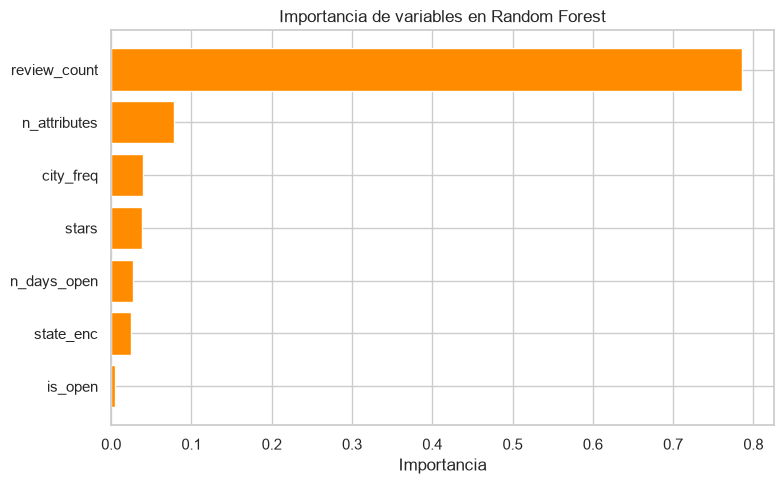

In [126]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred_log = rf.predict(X_test)
rf_pred_raw = np.expm1(rf_pred_log)

rf_metrics = {
    'MAE (log)': mean_absolute_error(y_test, rf_pred_log),
    'RMSE (log)': np.sqrt(mean_squared_error(y_test, rf_pred_log)),
    'R² (log)': r2_score(y_test, rf_pred_log),
    'MAE (orig)': mean_absolute_error(y_test_raw, rf_pred_raw),
    'RMSE (orig)': np.sqrt(mean_squared_error(y_test_raw, rf_pred_raw)),
}

print('Métricas de Random Forest regressor:')
for k, v in rf_metrics.items():
    print(f'{k}: {v:.4f}')

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importances.to_frame('Importancia'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index[::-1], importances.values[::-1], color='darkorange')
ax.set_title('Importancia de variables en Random Forest')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

#### Métricas características de Random Forest

- R² (log): indica qué tan bien explica la varianza el modelo en la escala transformada
- MAE y RMSE: reflejan la magnitud del error de predicción
- Importancia de variables: muestra qué features tienen más peso en la decisión del bosque

En general, este modelo suele superar al baseline lineal cuando existen interacciones no lineales o efectos no proporcionales entre las variables.

## 2) Clasificación: usuario elite vs no elite

En esta parte del análisis se construye una variable binaria: `elite_encoded = 1` si el usuario es elite y `0` en caso contrario. Luego se comparan varios modelos para ver qué tan bien separan el caso positivo.

In [127]:
# Preparación del dataset de clasificación

def classify_elite(value):
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        cleaned = value.strip()
        return 1 if cleaned not in ['', 'None', 'none', '[]'] else 0
    if isinstance(value, (list, tuple, set)):
        return 1 if len(value) > 0 else 0
    return 1 if bool(value) else 0

# La columna `elite` contiene los años en los que fue elite; un valor no vacío indica clase positiva.
df_user['is_elite'] = df_user['elite'].fillna('').astype(str).str.strip().ne('').astype(int)
df_binclass = df_user.copy()
df_binclass["elite_encoded"] = df_binclass["is_elite"].astype(int)
# 'is_elite' es la misma señal que el target (elite_encoded se construye a partir de ella): debe excluirse de las features, no solo 'elite'.
df_binclass = drop_if_exists(df_binclass, ['elite', 'is_elite', 'name', 'friends', 'elite_years', 'yelping_since', 'user_id'])
print(df_binclass['elite_encoded'].value_counts())
print(df_binclass.head())

elite_encoded
0    80138
1    19862
Name: count, dtype: int64
   review_count  useful  funny   cool  fans  average_stars  compliment_hot  \
0           585    7217   1259   5994   267         3.9100             250   
1          4333   43091  13066  27281  3138         3.7400            1145   
2           665    2086   1010   1003    52         3.3200              89   
3           224     512    330    299    28         4.2700              24   
4            79      29     15      7     1         3.5400               1   

   compliment_more  compliment_profile  compliment_cute  compliment_list  \
0               65                  55               56               18   
1              264                 184              157              251   
2               13                  10               17                3   
3                4                   1                6                2   
4                1                   0                0                0   

   complimen

In [128]:
def chequear_correl(df):
    matriz_correl = df.corr(method='pearson')

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        matriz_correl,
        cmap='coolwarm',
        annot=True,
        fmt='.2f',
        center=0
    )
    plt.title('Correlación entre atributos')
    plt.show()

    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    high_corr = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.8
    ]

    for c1, c2, corr_val in sorted(high_corr, key=lambda x: -x[2]):
        print(f'{c1} - {c2}: {corr_val:.3f}')


def rank_correlacionadas(df, target='elite_encoded', threshold=0.8):
    corr_features = df.drop(columns=[target]).corr().abs()
    target_corr = df.drop(columns=[target]).corrwith(df[target]).abs()
    upper = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))

    resultados = []
    for col in upper.columns:
        for row in upper.index:
            corr_value = upper.loc[row, col]
            if pd.notna(corr_value) and corr_value > threshold:
                resultados.append({
                    'feature_1': row,
                    'feature_2': col,
                    'feature_corr': corr_value,
                    'target_corr_1': target_corr[row],
                    'target_corr_2': target_corr[col],
                    'conservar': row if target_corr[row] > target_corr[col] else col,
                })

    return pd.DataFrame(resultados).sort_values('feature_corr', ascending=False)


def point_biserial_ranking(df, target='elite_encoded'):
    resultados = []
    for col in df.select_dtypes(include='number').columns:
        if col == target:
            continue
        corr, pvalue = pointbiserialr(df[target], df[col])
        resultados.append({
            'atributo': col,
            'correlación': corr,
            'pvalor': pvalue,
        })

    resultados = pd.DataFrame(resultados)
    return resultados.sort_values('correlación', key=abs, ascending=False)


def tune_classifier(model_name, estimator_factory, param_space, X_train, y_train, scoring='f1', n_trials=30, n_jobs=1, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    def objective(trial):
        params = {}
        for key, spec in param_space.items():
            if spec['type'] == 'float':
                params[key] = trial.suggest_float(key, spec['low'], spec['high'], log=spec.get('log', False))
            elif spec['type'] == 'int':
                params[key] = trial.suggest_int(key, spec['low'], spec['high'], log=spec.get('log', False))
            else:
                params[key] = trial.suggest_categorical(key, spec['choices'])

        model = estimator_factory(**params)
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=n_jobs)
        return scores.mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)

    print(f'\n--- {model_name} ---')
    print(f'Mejores hiperparámetros: {study.best_params}')
    print(f'Mejor CV {scoring.upper()}: {study.best_value:.4f}')
    return study.best_params

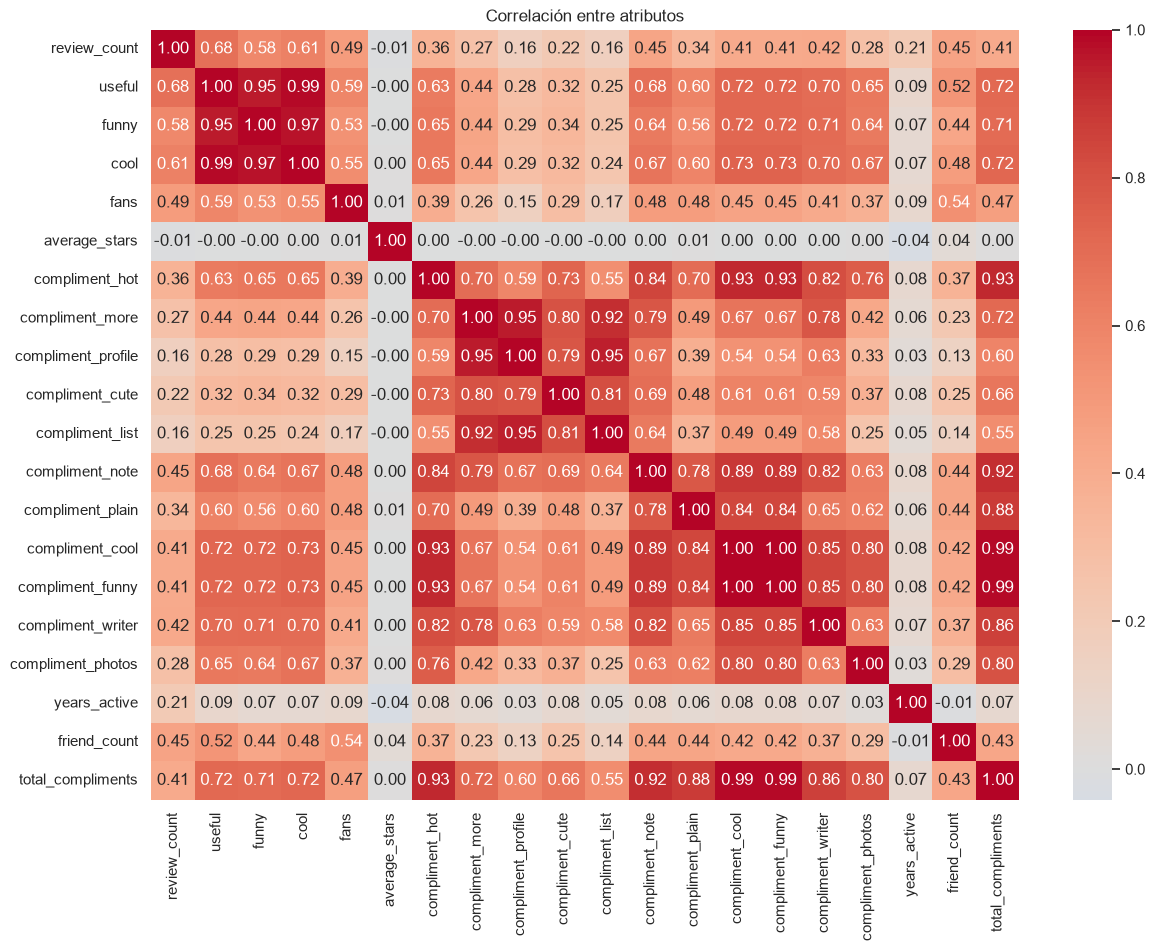

compliment_funny - compliment_cool: 1.000
cool - useful: 0.991
total_compliments - compliment_cool: 0.987
total_compliments - compliment_funny: 0.987
cool - funny: 0.970
funny - useful: 0.955
compliment_profile - compliment_more: 0.954
compliment_list - compliment_profile: 0.948
compliment_cool - compliment_hot: 0.932
compliment_funny - compliment_hot: 0.932
total_compliments - compliment_hot: 0.929
compliment_list - compliment_more: 0.917
total_compliments - compliment_note: 0.916
compliment_cool - compliment_note: 0.889
compliment_funny - compliment_note: 0.889
total_compliments - compliment_plain: 0.879
total_compliments - compliment_writer: 0.858
compliment_writer - compliment_cool: 0.845
compliment_writer - compliment_funny: 0.845
compliment_note - compliment_hot: 0.844
compliment_cool - compliment_plain: 0.837
compliment_funny - compliment_plain: 0.837
compliment_writer - compliment_hot: 0.817
compliment_writer - compliment_note: 0.816
compliment_list - compliment_cute: 0.814
com

In [129]:
df_dummy = df_binclass.drop(columns=['elite_encoded'])
chequear_correl(df_dummy)

In [130]:
rank_correlacionadas(df_binclass)

,feature_1,feature_2,feature_corr,target_corr_1,target_corr_2,conservar
15,compliment_cool,compliment_funny,1.0000,0.1541,0.1541,compliment_funny
1,useful,cool,0.9912,0.2112,0.1652,useful
24,compliment_funny,total_compliments,0.9865,0.1541,0.1493,compliment_funny
23,compliment_cool,total_compliments,0.9865,0.1541,0.1493,compliment_cool
2,funny,cool,0.9700,0.1464,0.1652,cool
0,useful,funny,0.9548,0.2112,0.1464,useful
3,compliment_more,compliment_profile,0.9537,0.1080,0.0501,compliment_more
6,compliment_profile,compliment_list,0.9480,0.0501,0.0546,compliment_list
12,compliment_hot,compliment_funny,0.9319,0.1360,0.1541,compliment_funny
9,compliment_hot,compliment_cool,0.9319,0.1360,0.1541,compliment_cool


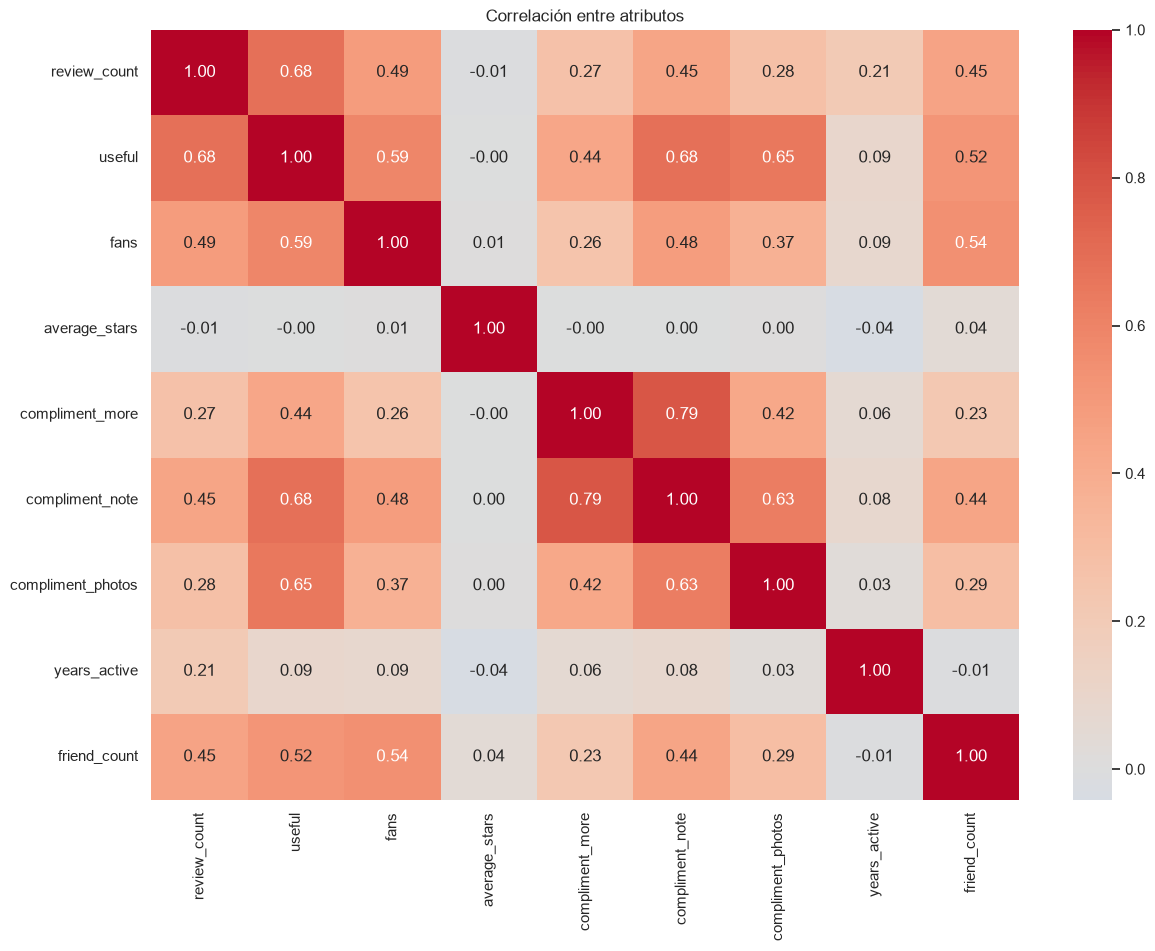

In [131]:
df_binclass = drop_if_exists(df_binclass, ['compliment_cool', 'cool', 'total_compliments', 'funny', 'compliment_profile', 'compliment_hot', 'compliment_list', 'compliment_funny', 'compliment_plain', 'compliment_writer', 'compliment_cute'])
df_dummy = df_binclass.drop(columns=['elite_encoded'])
chequear_correl(df_dummy)

In [132]:
point_biserial_ranking(df_binclass)

,atributo,correlación,pvalor
0,review_count,0.4678,0.0000
8,friend_count,0.2500,0.0000
1,useful,0.2112,0.0000
2,fans,0.2091,0.0000
5,compliment_note,0.1767,0.0000
7,years_active,0.1560,0.0000
4,compliment_more,0.1080,0.0000
6,compliment_photos,0.0898,0.0000
3,average_stars,0.0404,0.0000


## Definición de un baseline para el benchmark

En el EDA completo se observa que hay correlación entre las variables `review_count`, `fans`, `useful`, `cool`, `funny` y `years_active`.

Los gráficos siguientes muestran que los usuarios elite tienden a acumular más actividad y reputación, y por eso una regla simple basada en estas variables funciona muy bien como benchmark inicial antes de entrenar modelos más complejos.



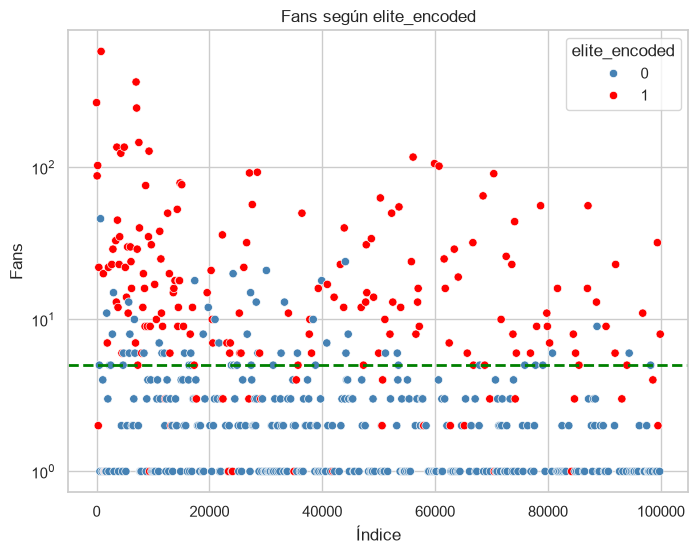

In [133]:
df_plot = df_binclass.iloc[::100]
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_plot,
    x=df_plot.index,
    y="fans",
    hue="elite_encoded",
    palette={0: "steelblue", 1: "red"}
)
plt.axhline(y=5, color='green', linestyle='--', linewidth=2, label='y = 5')
plt.yscale("log")
plt.xlabel("Índice")
plt.ylabel("Fans")
plt.title("Fans según elite_encoded")
plt.show()

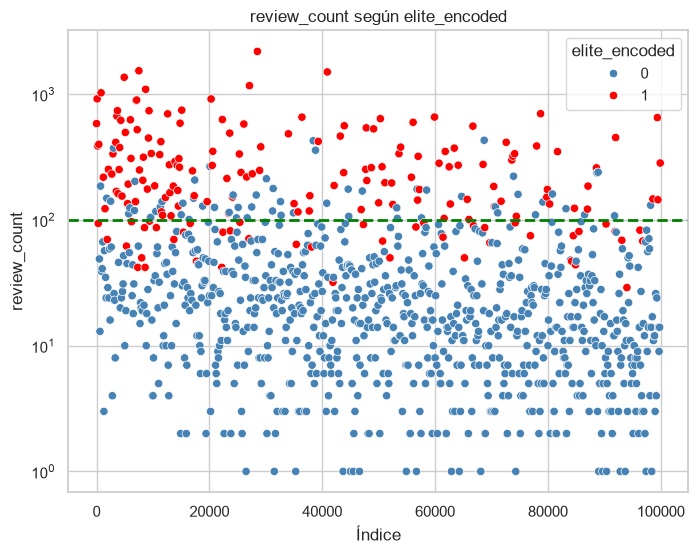

In [134]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_plot,
    x=df_plot.index,
    y="review_count",
    hue="elite_encoded",
    palette={0: "steelblue", 1: "red"}
)
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, label='y = 5')
plt.yscale("log")
plt.xlabel("Índice")
plt.ylabel("review_count")
plt.title("review_count según elite_encoded")
plt.show()

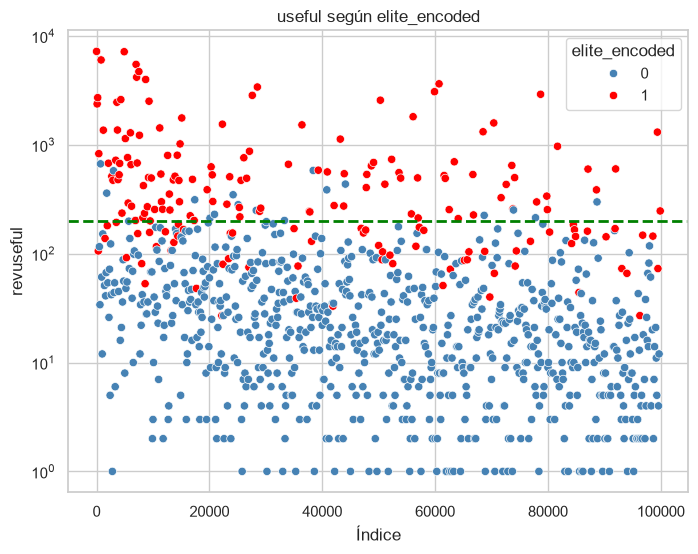

In [135]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_plot,
    x=df_plot.index,
    y="useful",
    hue="elite_encoded",
    palette={0: "steelblue", 1: "red"}
)
plt.axhline(y=200, color='green', linestyle='--', linewidth=2, label='y = 5')
plt.yscale("log")
plt.xlabel("Índice")
plt.ylabel("revuseful")
plt.title("useful según elite_encoded")
plt.show()

### Baseline heurístico

Antes de entrenar modelos más complejos, se define una heurística que combina tres indicadores de actividad y reputación del usuario.

Esta regla nace directamente del EDA: los usuarios elite presentan valores claramente más altos en `review_count`, `fans` y `useful`, como se observa en los gráficos del análisis exploratorio. Por eso se usa como benchmark inicial y como referencia para evaluar si un modelo más sofisticado realmente aporta valor.

Regla:
- más de 100 reviews
- más de 5 fans
- más de 200 votos useful

Si al menos 2 de 3 condiciones se cumplen, se clasifica como elite.


In [136]:
class HeuristicaElite:
    def predict_score(self, X):
        return (
            (X["review_count"] > 100).astype(int) +
            (X["fans"] > 5).astype(int) +
            (X["useful"] > 200).astype(int)
        )

    def predict(self, X):
        return (self.predict_score(X) >= 2).astype(int)


X_binclass = df_binclass.drop(columns=['elite_encoded'])
y_binclass = df_binclass['elite_encoded']
X_binclass_train, X_binclass_test, y_binclass_train, y_binclass_test = train_test_split(
    X_binclass,
    y_binclass,
    test_size=0.2,
    random_state=42,
    stratify=y_binclass,
)

heuristica = HeuristicaElite()
y_binclass_pred_heur = heuristica.predict(X_binclass_test)
y_binclass_score_heur = heuristica.predict_score(X_binclass_test)

print(f"Exactitud =, {accuracy_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"F1 =, {f1_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"Precisión =, {precision_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"Recall =, {recall_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"ROC-AUC =, {roc_auc_score(y_binclass_test, y_binclass_score_heur):.4f}")

Exactitud =, 0.9124
F1 =, 0.7647
Precisión =, 0.8201
Recall =, 0.7163
ROC-AUC =, 0.9038


Se ve que la heurística funciona bien y es extremadamente liviana desde el punto de vista de carga computacional asique nos quedamos con ésta

Se omite Heuristica porque no está disponible en este entorno.


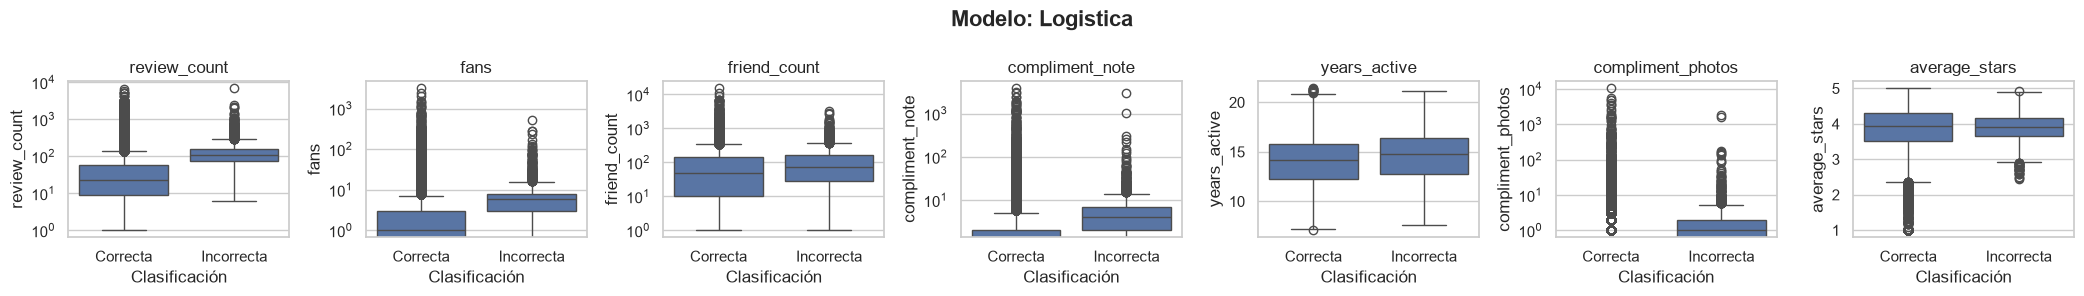

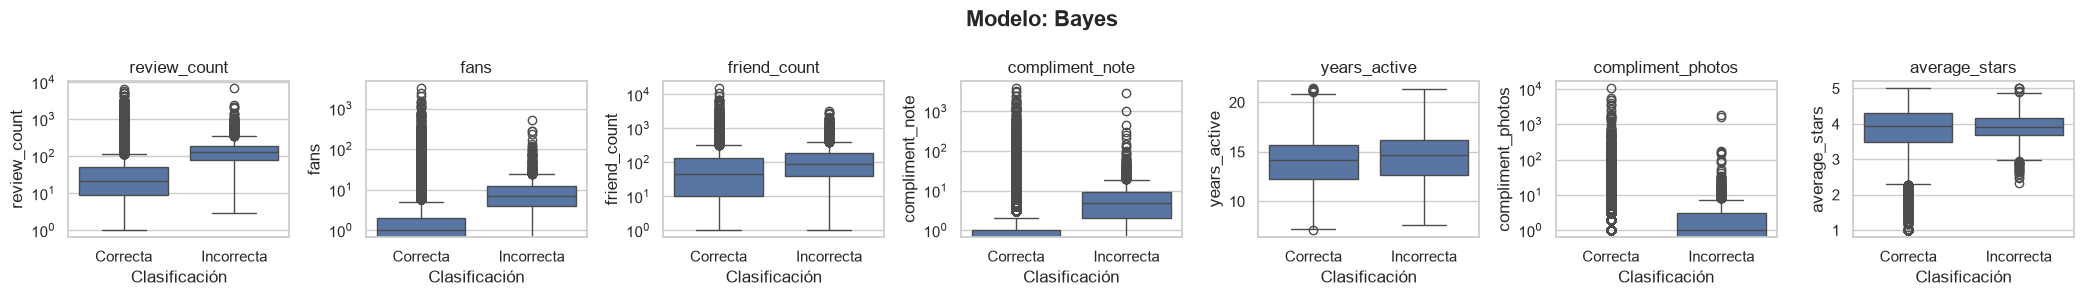

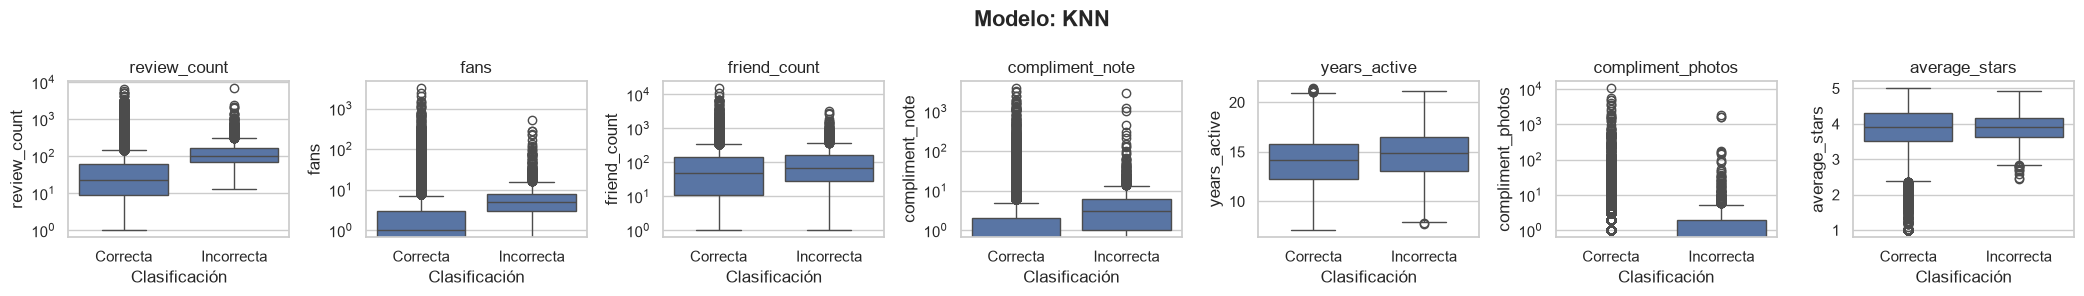

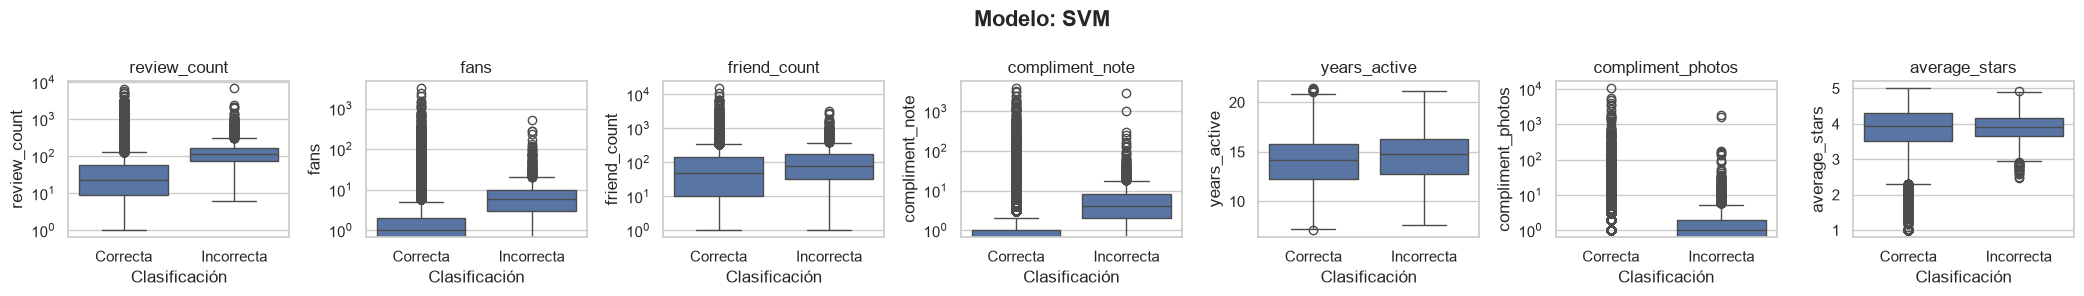

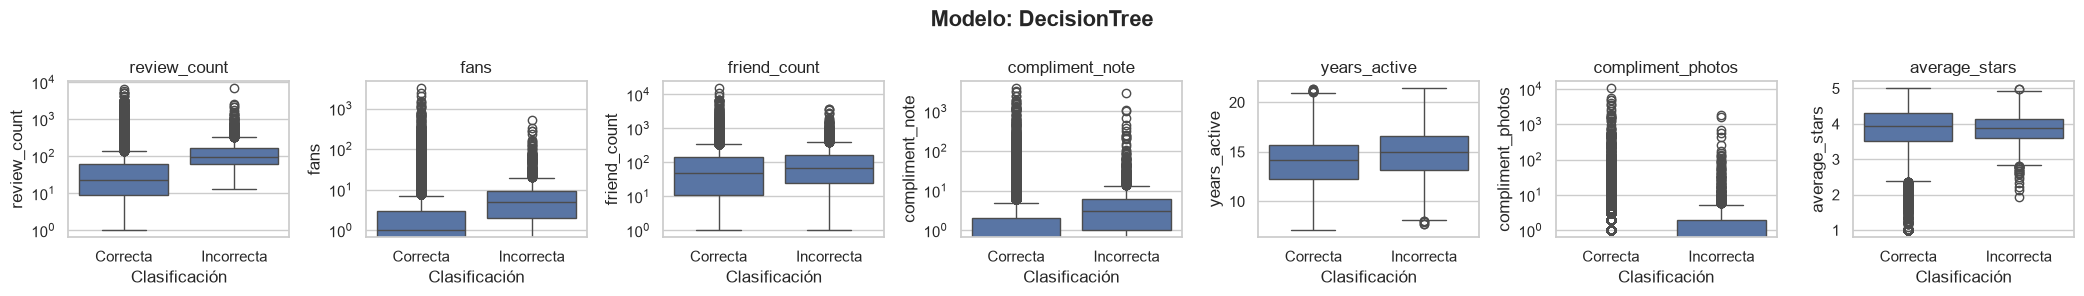

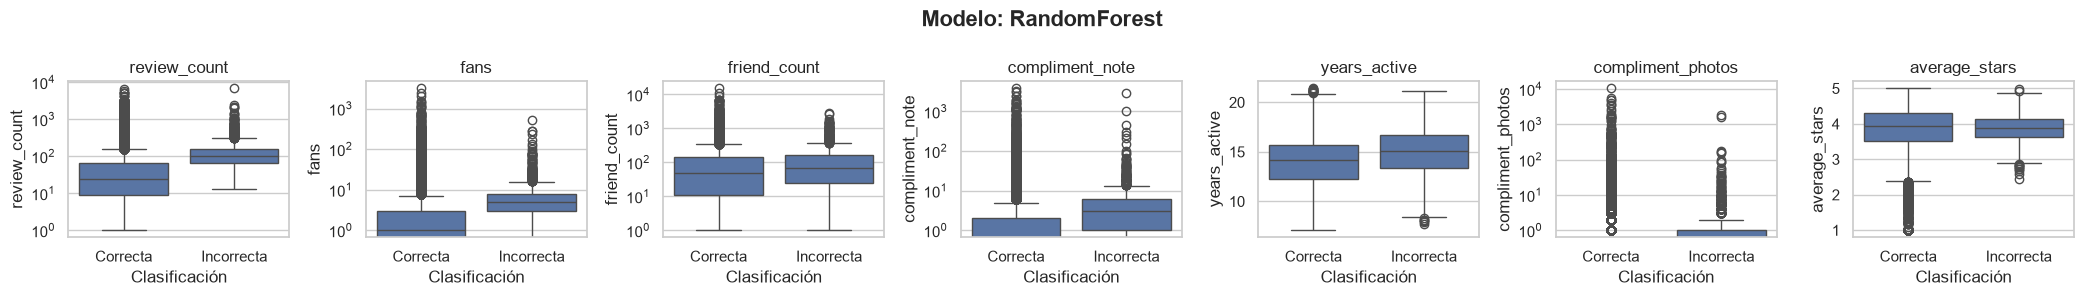

Se omite XGBoost porque no está disponible en este entorno.

Métricas comparativas:


,Exactitud,F1,Precisión,Recall,ROC-AUC
Logistica,0.9010,0.7024,0.8714,0.5884,0.9591
Bayes,0.8660,0.5249,0.8878,0.3726,0.9157
KNN,0.9163,0.7756,0.8294,0.7283,0.9367
SVM,0.8871,0.6357,0.8850,0.4960,0.9600
DecisionTree,0.9030,0.7551,0.7577,0.7525,0.8464
RandomForest,0.9328,0.8259,0.8512,0.8021,0.9750


In [137]:
# from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# from sklearn.svm import LinearSVC

try:
    from xgboost import XGBClassifier, plot_importance
except ModuleNotFoundError:
    XGBClassifier = None
    def plot_importance(*args, **kwargs):
        raise ModuleNotFoundError("xgboost no está instalado. Instálalo con: pip install xgboost")

modelos = {
    "Heuristica": None,
    "Logistica": LogisticRegression(max_iter=1000),
    "Bayes": GaussianNB(var_smoothing=1e-9),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": LinearSVC(random_state=42, max_iter=5000), #SVC(probability=True, random_state=42), #LinearSVC(random_state=42, max_iter=5000)
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(objective='binary:logistic') if XGBClassifier is not None else None,
}

atributos = ['review_count', 'fans', 'friend_count', 'compliment_note', 'years_active', 'compliment_photos', 'average_stars']
cant_attr = len(atributos)

results = {}

# Reconstituir el dataset de clasificación dentro del mismo bloque para evitar dependencia del orden de ejecución
if 'df_user' not in globals():
    BASE_PATH = find_datasets_dir()
    df_user = read_json_sample(BASE_PATH / 'yelp_academic_dataset_user.json', nrows=SAMPLE_ROWS)
    df_user['elite'] = df_user['elite'].apply(lambda x: 'Elite' if isinstance(x, str) and len(x) > 0 else 'Non-Elite')
    df_user['yelping_since'] = pd.to_datetime(df_user['yelping_since'])
    df_user['years_active'] = (pd.Timestamp('2026-05-31') - df_user['yelping_since']).dt.days / 365.25
    df_user['friend_count'] = df_user['friends'].apply(lambda x: 0 if (x == 'None' or x == '') else len(str(x).split(',')))
    df_user['elite_years'] = df_user['elite'].apply(lambda x: 0 if (x == '' or pd.isna(x)) else len(str(x).split(',')))
    compliment_cols = [c for c in df_user.columns if c.startswith('compliment_')]
    df_user['total_compliments'] = df_user[compliment_cols].sum(axis=1)

if 'df_binclass' not in globals():
    df_binclass = df_user.copy()
    df_binclass["elite_encoded"] = (df_binclass["elite"] == "Elite").astype(int)
    df_binclass = df_binclass.drop(columns=['elite', 'name', 'friends', 'elite_years', 'yelping_since', 'user_id'])
    df_binclass = df_binclass.drop(columns=['compliment_cool', 'cool', 'total_compliments', 'funny', 'compliment_profile', 'compliment_hot', 'compliment_list', 'compliment_funny', 'compliment_cool', 'compliment_plain', 'total_compliments', 'compliment_writer', 'compliment_cute'])

X_binclass = df_binclass.drop(columns=["elite_encoded"])
y_binclass = df_binclass["elite_encoded"]
X_binclass_train, X_binclass_test, y_binclass_train, y_binclass_test = train_test_split(
    X_binclass,
    y_binclass,
    test_size=0.2,
    random_state=42,
    stratify=y_binclass,
)

scaler = StandardScaler()
X_binclass_train_scaled = scaler.fit_transform(X_binclass_train)
X_binclass_test_scaled = scaler.transform(X_binclass_test)

heuristica = HeuristicaElite()

for nombre, modelo in modelos.items():
    if modelo is None:
        print(f"Se omite {nombre} porque no está disponible en este entorno.")
        continue

    if nombre == "Heuristica":
        y_pred = heuristica.predict(X_binclass_test)
        y_score = heuristica.predict_score(X_binclass_test)

    elif nombre in ["Logistica", "Bayes", "KNN", "SVM"]:
        modelo.fit(X_binclass_train_scaled, y_binclass_train)
        y_pred = modelo.predict(X_binclass_test_scaled)
        if hasattr(modelo, "predict_proba"):
            y_score = modelo.predict_proba(X_binclass_test_scaled)[:, 1]
        else:
            y_score = modelo.decision_function(X_binclass_test_scaled)
    
    else:
        modelo.fit(X_binclass_train, y_binclass_train)
        y_pred = modelo.predict(X_binclass_test)
        y_score = modelo.predict_proba(X_binclass_test)[:, 1]
        if nombre == "XGBoost":
            plt.figure(figsize=(10, 6))
            plot_importance(modelo, max_num_features=10)
            plt.title("Importancia de atrinutos - XGBoost")
            plt.show()

    df_eval = X_binclass_test.copy()
    df_eval["error"] = (y_pred != y_binclass_test.values)
    df_eval["clasificacion"] = df_eval["error"].map({False: "Correcta", True: "Incorrecta"})

    fig, axes = plt.subplots(nrows=1, ncols=cant_attr, figsize=(3*cant_attr, 3), sharey=False)
    fig.suptitle(f"Modelo: {nombre}", fontsize=16, fontweight="bold")
    for ax, atributo in zip(axes, atributos):
        sns.boxplot(data=df_eval, x="clasificacion", y=atributo, ax=ax)
        ax.set_title(atributo)
        if atributo not in ["years_active", "average_stars"]:
            ax.set_yscale("log")
        ax.set_xlabel("Clasificación")
        plt.tight_layout()
    plt.show()

    results[nombre] = {
        'Exactitud': accuracy_score(y_binclass_test, y_pred),
        'F1': f1_score(y_binclass_test, y_pred),
        'Precisión': precision_score(y_binclass_test, y_pred),
        'Recall': recall_score(y_binclass_test, y_pred),
        'ROC-AUC': roc_auc_score(y_binclass_test, y_score),
    }

metrics = pd.DataFrame(results).T
print('\nMétricas comparativas:')
display(metrics.round(4))

#### Métricas características de la heurística

- Exactitud: proporción de predicciones correctas
- F1: equilibrio entre precision y recall
- Precisión: proporción de positivos predichos correctamente
- Recall: capacidad de detectar verdaderos positivos
- ROC-AUC: capacidad global de ordenamiento del modelo

La heurística funciona bien como baseline ligero y computacionalmente barato. Es útil para comparar modelos más complejos.

### Modelo 3: regresión logística

La regresión logística es un modelo lineal clásico para clasificación binaria. Como muchas variables tienen escalas distintas, se aplica `StandardScaler` antes de entrenar. Los hiperparámetros se optimizan con Optuna usando validación cruzada estratificada.

In [138]:
scaler = StandardScaler()
X_binclass_train_scaled = scaler.fit_transform(X_binclass_train)
X_binclass_test_scaled = scaler.transform(X_binclass_test)

best_logistic_params = tune_classifier(
    'Regresión Logística',
    lambda **params: LogisticRegression(max_iter=2000, **params),
    {
        'C': {'type': 'float', 'low': 1e-2, 'high': 1e2, 'log': True},
        'solver': {'type': 'categorical', 'choices': ['lbfgs', 'liblinear']},
        'penalty': {'type': 'categorical', 'choices': ['l2']},
    },
    X_binclass_train_scaled,
    y_binclass_train,
    scoring='f1',
    n_trials=25,
)

logistica = LogisticRegression(max_iter=2000, **best_logistic_params)
logistica.fit(X_binclass_train_scaled, y_binclass_train)
y_pred_logistica = logistica.predict(X_binclass_test_scaled)
y_score_logistica = logistica.predict_proba(X_binclass_test_scaled)[:, 1]

logistica_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_logistica),
    'F1': f1_score(y_binclass_test, y_pred_logistica),
    'Precisión': precision_score(y_binclass_test, y_pred_logistica),
    'Recall': recall_score(y_binclass_test, y_pred_logistica),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_logistica),
}

print('Métricas de Regresión Logística:')
for k, v in logistica_metrics.items():
    print(f'{k}: {v:.4f}')

[I 2026-08-22 01:16:32,732] A new study created in memory with name: no-name-8e272496-1e85-4c4b-9bd1-9d3a30ebaec9
c:\Users\Leoes\.conda\envs\tp\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Leoes\.conda\envs\tp\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elas


--- Regresión Logística ---
Mejores hiperparámetros: {'C': 44.43928579434507, 'solver': 'lbfgs', 'penalty': 'l2'}
Mejor CV F1: 0.7111
Métricas de Regresión Logística:
Exactitud: 0.9016
F1: 0.7049
Precisión: 0.8717
Recall: 0.5916
ROC-AUC: 0.9587


#### Métricas características de la regresión logística

- Exactitud: porcentaje de aciertos globales
- F1: útil si hay desbalance de clases
- Precisión: mide cuántos de los clasificados como elite realmente lo son
- Recall: mide cuántos elite reales fueron detectados
- ROC-AUC: capacidad discriminativa del modelo

Este modelo es interpretable y sirve como comparación directa con modelos más complejos.

### Modelo 4: SVM

Support Vector Machine es un modelo potente para separación de clases. En este caso, se usa una versión lineal y se escala el conjunto antes del entrenamiento. Los hiperparámetros se encuentran con Optuna.# Asegurar columnas necesarias para los gráficos y la comparación de modelos

In [139]:
best_svm_params = tune_classifier(
    'SVM',
    lambda **params: LinearSVC(random_state=42, max_iter=5000, **params),
    {
        'C': {'type': 'float', 'low': 1e-2, 'high': 10, 'log': True},
        'penalty': {'type': 'categorical', 'choices': ['l2']},
        'loss': {'type': 'categorical', 'choices': ['hinge', 'squared_hinge']},
    },
    X_binclass_train_scaled,
    y_binclass_train,
    scoring='f1',
    n_trials=4,
    n_jobs=1,
    n_splits=2,
)

svm = LinearSVC(random_state=42, max_iter=5000, **best_svm_params)
svm.fit(X_binclass_train_scaled, y_binclass_train)
y_pred_svm = svm.predict(X_binclass_test_scaled)
y_score_svm = svm.decision_function(X_binclass_test_scaled)

svm_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_svm),
    'F1': f1_score(y_binclass_test, y_pred_svm),
    'Precisión': precision_score(y_binclass_test, y_pred_svm),
    'Recall': recall_score(y_binclass_test, y_pred_svm),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_svm),
}

print('Métricas de SVM:')
for k, v in svm_metrics.items():
    print(f'{k}: {v:.4f}')


[I 2026-08-22 01:16:46,180] A new study created in memory with name: no-name-5703274a-89f7-4c2b-8d8e-538df54d5f23
c:\Users\Leoes\.conda\envs\tp\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Leoes\.conda\envs\tp\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
[I 2026-08-22 01:16:46,272] Trial 0 finished with value: 0.7305707645452728 and parameters: {'C': 0.13292918943162169, 'penalty': 'l2', 'loss': 'hinge'}. Best is trial 0 with value: 0.7305707645452728.
c:\Users\Leoes\.conda\envs\tp\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Leoes\.conda\envs\tp\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of itera


--- SVM ---
Mejores hiperparámetros: {'C': 0.6251373574521749, 'penalty': 'l2', 'loss': 'hinge'}
Mejor CV F1: 0.7379
Métricas de SVM:
Exactitud: 0.9081
F1: 0.7299
Precisión: 0.8768
Recall: 0.6251
ROC-AUC: 0.9619


c:\Users\Leoes\.conda\envs\tp\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### Métricas características del SVM

- Exactitud: proporción de predicciones correctas
- F1: balance entre precisión y recall
- ROC-AUC: capacidad de separar ambas clases en la frontera aprendida
- Precisión y recall: útiles para detectar si el modelo prioriza evitar falsos positivos o falsos negativos

El SVM suele rendir bien cuando la separación entre clases es clara, pero la escala de las variables es clave para su desempeño.

### Modelo 5: decision tree classifier

El árbol de decisión es interpretable y aprende reglas simples a partir de los atributos. Los hiperparámetros se optimizan con Optuna para equilibrar complejidad y generalización.

In [140]:
best_dt_params = tune_classifier(
    'Decision Tree',
    lambda **params: DecisionTreeClassifier(random_state=42, **params),
    {
        'max_depth': {'type': 'int', 'low': 2, 'high': 20},
        'min_samples_split': {'type': 'int', 'low': 2, 'high': 20},
        'min_samples_leaf': {'type': 'int', 'low': 1, 'high': 10},
        'ccp_alpha': {'type': 'float', 'low': 1e-6, 'high': 1e-2, 'log': True},
    },
    X_binclass_train,
    y_binclass_train,
    scoring='f1',
    n_trials=25,
)

dt = DecisionTreeClassifier(random_state=42, **best_dt_params)
dt.fit(X_binclass_train, y_binclass_train)

y_pred_dt = dt.predict(X_binclass_test)
y_score_dt = dt.predict_proba(X_binclass_test)[:, 1]

dt_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_dt),
    'F1': f1_score(y_binclass_test, y_pred_dt),
    'Precisión': precision_score(y_binclass_test, y_pred_dt),
    'Recall': recall_score(y_binclass_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_dt),
}

print('Métricas de Decision Tree:')
for k, v in dt_metrics.items():
    print(f'{k}: {v:.4f}')

[I 2026-08-22 01:16:46,927] A new study created in memory with name: no-name-4c4db7d3-a4a9-490e-85e5-806efc4e0f7a
[I 2026-08-22 01:16:47,646] Trial 0 finished with value: 0.8009240968977801 and parameters: {'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 8, 'ccp_alpha': 0.0002481040974867811}. Best is trial 0 with value: 0.8009240968977801.
[I 2026-08-22 01:16:48,006] Trial 1 finished with value: 0.7914523643451603 and parameters: {'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 1, 'ccp_alpha': 0.0029154431891537554}. Best is trial 0 with value: 0.8009240968977801.
[I 2026-08-22 01:16:48,916] Trial 2 finished with value: 0.7577510836947808 and parameters: {'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'ccp_alpha': 0.00757947995334801}. Best is trial 0 with value: 0.8009240968977801.
[I 2026-08-22 01:16:49,921] Trial 3 finished with value: 0.7697442018739648 and parameters: {'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 2, 'ccp_


--- Decision Tree ---
Mejores hiperparámetros: {'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 7, 'ccp_alpha': 9.328435334022509e-05}
Mejor CV F1: 0.8121
Métricas de Decision Tree:
Exactitud: 0.9274
F1: 0.8112
Precisión: 0.8383
Recall: 0.7858
ROC-AUC: 0.9698


#### Métricas características del Decision Tree

- Exactitud y F1: muestran cómo de bien generaliza el árbol
- Precisión/Recall: indican la sensibilidad del árbol a errores de clasificación
- ROC-AUC: mide la separabilidad de clases bajo el árbol

Es muy interpretable, pero debe controlarse el overfitting porque el árbol puede memorizar patrones del conjunto de entrenamiento.

### Modelo 6: random forest classifier

El random forest classifier combina varios árboles para reducir la varianza del modelo individual y ofrecer un clasificador más robusto. Su configuración también se optimiza con Optuna.

In [141]:
best_rf_params = tune_classifier(
    'Random Forest',
    lambda **params: RandomForestClassifier(random_state=42, n_jobs=-1, **params),
    {
        'n_estimators': {'type': 'int', 'low': 100, 'high': 500},
        'max_depth': {'type': 'int', 'low': 2, 'high': 20},
        'min_samples_split': {'type': 'int', 'low': 2, 'high': 20},
        'min_samples_leaf': {'type': 'int', 'low': 1, 'high': 10},
        'max_features': {'type': 'categorical', 'choices': ['sqrt', 'log2', None]},
    },
    X_binclass_train,
    y_binclass_train,
    scoring='f1',
    n_trials=25,
)

rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1, **best_rf_params)
rf_clf.fit(X_binclass_train, y_binclass_train)

y_pred_rf = rf_clf.predict(X_binclass_test)
y_score_rf = rf_clf.predict_proba(X_binclass_test)[:, 1]

rf_clf_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_rf),
    'F1': f1_score(y_binclass_test, y_pred_rf),
    'Precisión': precision_score(y_binclass_test, y_pred_rf),
    'Recall': recall_score(y_binclass_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_rf),
}

print('Métricas de Random Forest Classifier:')
for k, v in rf_clf_metrics.items():
    print(f'{k}: {v:.4f}')

[I 2026-08-22 01:17:05,611] A new study created in memory with name: no-name-e177f3dd-97ad-46ed-bcfc-ba29c70ea547
[I 2026-08-22 01:17:12,975] Trial 0 finished with value: 0.8297387774820912 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8297387774820912.
[I 2026-08-22 01:17:24,855] Trial 1 finished with value: 0.8298414382866653 and parameters: {'n_estimators': 447, 'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8298414382866653.
[I 2026-08-22 01:17:30,694] Trial 2 finished with value: 0.8115258844539925 and parameters: {'n_estimators': 172, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 1 with value: 0.8298414382866653.
[I 2026-08-22 01:17:34,091] Trial 3 finished with value: 0.8234916625639679 and parameters: {'n_estimators': 155, 'max_depth': 7, 'min


--- Random Forest ---
Mejores hiperparámetros: {'n_estimators': 356, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 'log2'}
Mejor CV F1: 0.8309
Métricas de Random Forest Classifier:
Exactitud: 0.9335
F1: 0.8272
Precisión: 0.8539
Recall: 0.8021
ROC-AUC: 0.9771


#### Métricas características del Random Forest Classifier

- Exactitud: representa la capacidad global del modelo
- F1: una métrica muy útil cuando la clase positiva es minoritaria
- Precisión y recall: ayudan a entender si el modelo prioriza evitar falsos positivos o detectar más casos reales
- ROC-AUC: refleja la capacidad del modelo para distinguir entre clases

Este modelo suele ofrecer un equilibrio sólido entre rendimiento, estabilidad y capacidad de modelado no lineal.

In [142]:
# Resumen comparativo final
results = {
    'Heurística': {
        'Exactitud': accuracy_score(y_binclass_test, y_binclass_pred_heur),
        'F1': f1_score(y_binclass_test, y_binclass_pred_heur),
        'Precisión': precision_score(y_binclass_test, y_binclass_pred_heur),
        'Recall': recall_score(y_binclass_test, y_binclass_pred_heur),
        'ROC-AUC': roc_auc_score(y_binclass_test, y_binclass_score_heur),
    },
    'Regresión Logística': logistica_metrics,
    'SVM': svm_metrics,
    'Decision Tree': dt_metrics,
    'Random Forest': rf_clf_metrics,
}

metrics_df = pd.DataFrame(results).T
print('\nComparación final de modelos de clasificación:')
display(metrics_df.round(4))


Comparación final de modelos de clasificación:


,Exactitud,F1,Precisión,Recall,ROC-AUC
Heurística,0.9124,0.7647,0.8201,0.7163,0.9038
Regresión Logística,0.9016,0.7049,0.8717,0.5916,0.9587
SVM,0.9081,0.7299,0.8768,0.6251,0.9619
Decision Tree,0.9274,0.8112,0.8383,0.7858,0.9698
Random Forest,0.9334,0.8272,0.8539,0.8021,0.9771


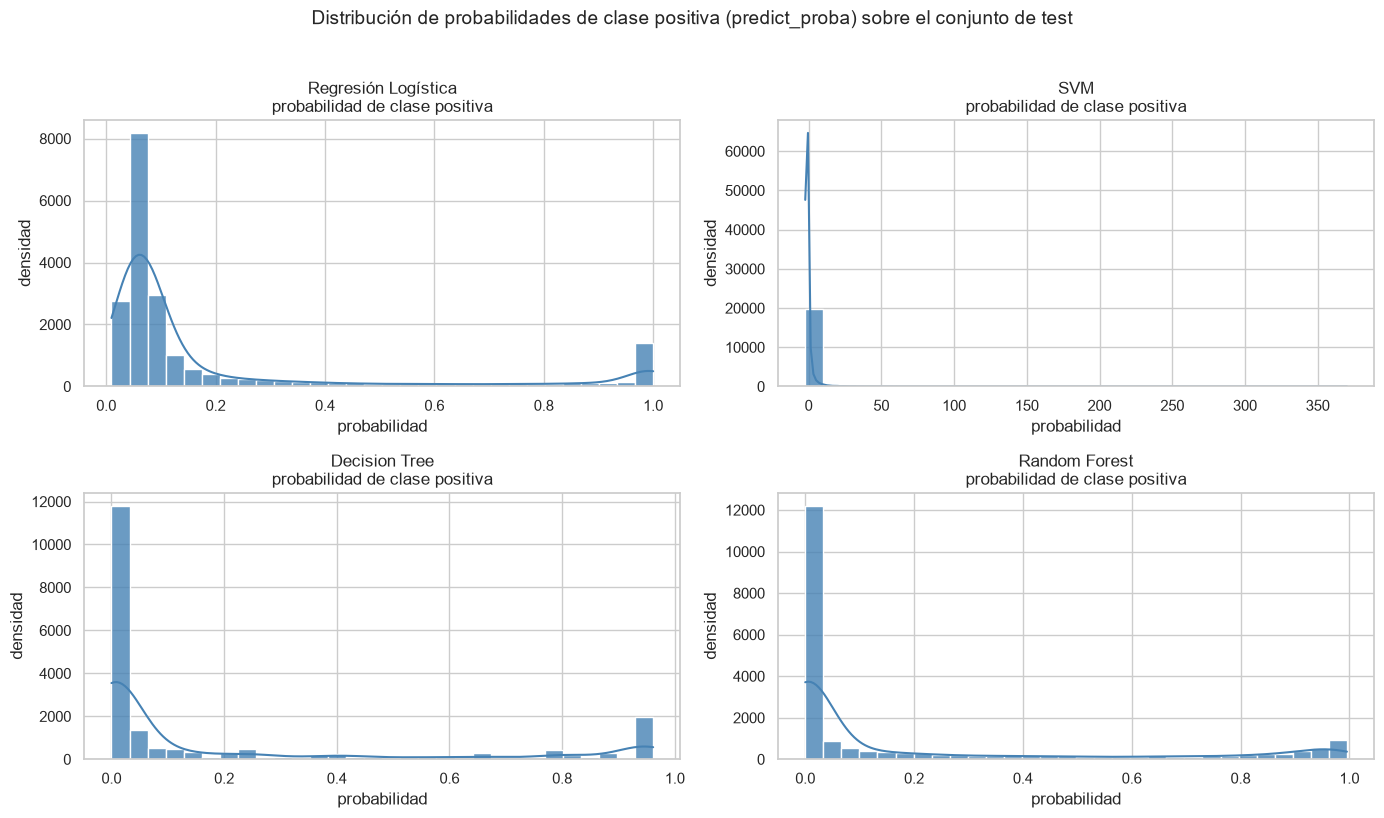

In [143]:
# Distribuciones de probabilidades de clase positiva usando predict_proba() en el conjunto de test

probabilities_by_model = {
    'Regresión Logística': y_score_logistica,
    'SVM': y_score_svm,
    'Decision Tree': y_score_dt,
    'Random Forest': y_score_rf,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for ax, (name, probs) in zip(axes, probabilities_by_model.items()):
    sns.histplot(probs, bins=30, kde=True, color='steelblue', alpha=0.8, ax=ax)
    ax.set_title(f'{name}\nprobabilidad de clase positiva')
    ax.set_xlabel('probabilidad')
    ax.set_ylabel('densidad')

for ax in axes[len(probabilities_by_model):]:
    ax.axis('off')

fig.suptitle('Distribución de probabilidades de clase positiva (predict_proba) sobre el conjunto de test', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3) Evaluación adicional para clase minoritaria

La comparación anterior se apoya en Exactitud, F1, Precisión, Recall y ROC-AUC, pero para un target desbalanceado como `elite_encoded` (~20% positivos en la muestra) eso puede quedarse corto: el ROC-AUC se infla con la gran cantidad de negativos verdaderos, y ninguno de los "modelos" se comparó nunca contra una línea base verdaderamente trivial. Se completa el análisis con:

- **Matriz de confusión** por modelo, para ver dónde se concentran los errores.
- **PR-AUC** (`average_precision_score`), más informativo que ROC-AUC bajo desbalance porque se centra en la clase positiva.
- Un **baseline trivial real** (`DummyClassifier`), a diferencia de la heurística que ya usa señal genuina del dataset.
- Una corrida con **`class_weight='balanced'`** sobre los dos modelos tuneados más representativos (Regresión Logística y Random Forest), para ver si cambia el trade-off precisión/recall en la clase elite.

### 3.1 Baseline trivial (`DummyClassifier`)

La heurística ya usa señal real (`review_count`, `fans`, `useful`), así que no sirve como piso verdadero. Un `DummyClassifier` que siempre predice la clase mayoritaria da el punto de referencia mínimo: cualquier modelo entrenado debería superarlo claramente, sobre todo en F1/Recall/PR-AUC de la clase elite.

In [144]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_binclass_train, y_binclass_train)
y_pred_dummy = dummy.predict(X_binclass_test)
y_score_dummy = dummy.predict_proba(X_binclass_test)[:, 1]

dummy_metrics = {
    'Exactitud': accuracy_score(y_binclass_test, y_pred_dummy),
    'F1': f1_score(y_binclass_test, y_pred_dummy, zero_division=0),
    'Precisión': precision_score(y_binclass_test, y_pred_dummy, zero_division=0),
    'Recall': recall_score(y_binclass_test, y_pred_dummy, zero_division=0),
    'ROC-AUC': roc_auc_score(y_binclass_test, y_score_dummy),
    'PR-AUC': average_precision_score(y_binclass_test, y_score_dummy),
}

print("Métricas del baseline trivial (DummyClassifier):")
for k, v in dummy_metrics.items():
    print(f'{k}: {v:.4f}')


Métricas del baseline trivial (DummyClassifier):
Exactitud: 0.8014
F1: 0.0000
Precisión: 0.0000
Recall: 0.0000
ROC-AUC: 0.5000
PR-AUC: 0.1986


### 3.2 Matriz de confusión y PR-AUC por modelo

Se calculan ambas métricas para todos los modelos ya entrenados (Dummy, Heurística y los cuatro modelos tuneados con Optuna), reutilizando las predicciones y scores calculados en las secciones anteriores.

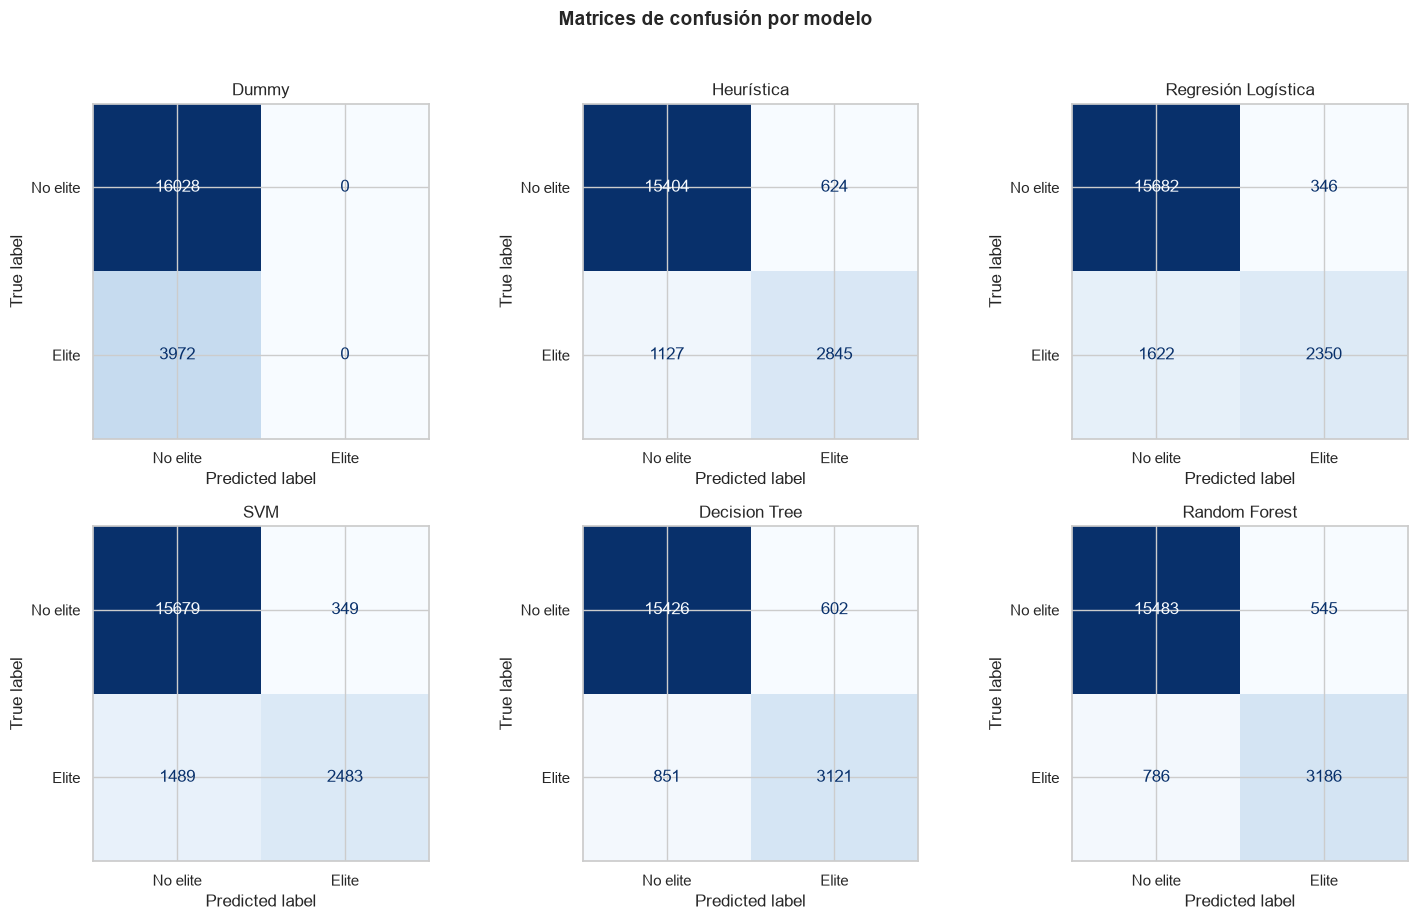

PR-AUC por modelo:
Dummy: 0.1986
Heurística: 0.7477
Regresión Logística: 0.8483
SVM: 0.8626
Decision Tree: 0.8807
Random Forest: 0.9134


In [145]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_by_model = {
    'Dummy': (y_pred_dummy, y_score_dummy),
    'Heurística': (y_binclass_pred_heur, y_binclass_score_heur),
    'Regresión Logística': (y_pred_logistica, y_score_logistica),
    'SVM': (y_pred_svm, y_score_svm),
    'Decision Tree': (y_pred_dt, y_score_dt),
    'Random Forest': (y_pred_rf, y_score_rf),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

pr_auc_scores = {}
for ax, (nombre, (y_pred, y_score)) in zip(axes, pred_by_model.items()):
    cm = confusion_matrix(y_binclass_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No elite', 'Elite']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
    pr_auc_scores[nombre] = average_precision_score(y_binclass_test, y_score)

fig.suptitle('Matrices de confusión por modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('PR-AUC por modelo:')
for k, v in pr_auc_scores.items():
    print(f'{k}: {v:.4f}')


### 3.3 Comparación final actualizada (incluye Dummy y PR-AUC)

Se extiende la tabla `metrics_df` de la comparación final con la fila del baseline trivial y la columna de PR-AUC, y se ordena por esta última.

In [146]:
metrics_df_full = metrics_df.copy()
metrics_df_full.loc['Dummy', ['Exactitud', 'F1', 'Precisión', 'Recall', 'ROC-AUC']] = [
    dummy_metrics['Exactitud'], dummy_metrics['F1'], dummy_metrics['Precisión'],
    dummy_metrics['Recall'], dummy_metrics['ROC-AUC'],
]
metrics_df_full['PR-AUC'] = pd.Series(pr_auc_scores)
metrics_df_full = metrics_df_full.sort_values('PR-AUC', ascending=False)

print('Comparación final de modelos de clasificación (con Dummy y PR-AUC):')
display(metrics_df_full.round(4))


Comparación final de modelos de clasificación (con Dummy y PR-AUC):


,Exactitud,F1,Precisión,Recall,ROC-AUC,PR-AUC
Random Forest,0.9334,0.8272,0.8539,0.8021,0.9771,0.9134
Decision Tree,0.9274,0.8112,0.8383,0.7858,0.9698,0.8807
SVM,0.9081,0.7299,0.8768,0.6251,0.9619,0.8626
Regresión Logística,0.9016,0.7049,0.8717,0.5916,0.9587,0.8483
Heurística,0.9124,0.7647,0.8201,0.7163,0.9038,0.7477
Dummy,0.8014,0.0000,0.0000,0.0000,0.5000,0.1986


### 3.4 Efecto de `class_weight='balanced'`

Se reentrenan la Regresión Logística y el Random Forest —los mismos hiperparámetros encontrados con Optuna en las secciones 2.3 y 2.6— agregando `class_weight='balanced'`, para ver si el cambio en la ponderación de clases mueve el trade-off precisión/recall sobre la clase elite.

c:\Users\Leoes\.conda\envs\tp\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Tuneado vs. class_weight='balanced':


,Exactitud,F1,Precisión,Recall,ROC-AUC,PR-AUC
Regresión Logística,0.9016,0.7049,0.8717,0.5916,0.9587,0.8483
Regresión Logística (balanced),0.9168,0.7994,0.7669,0.8348,0.9649,0.8598
Random Forest,0.9334,0.8272,0.8539,0.8021,0.9771,0.9134
Random Forest (balanced),0.9228,0.8253,0.7494,0.9184,0.9772,0.9126


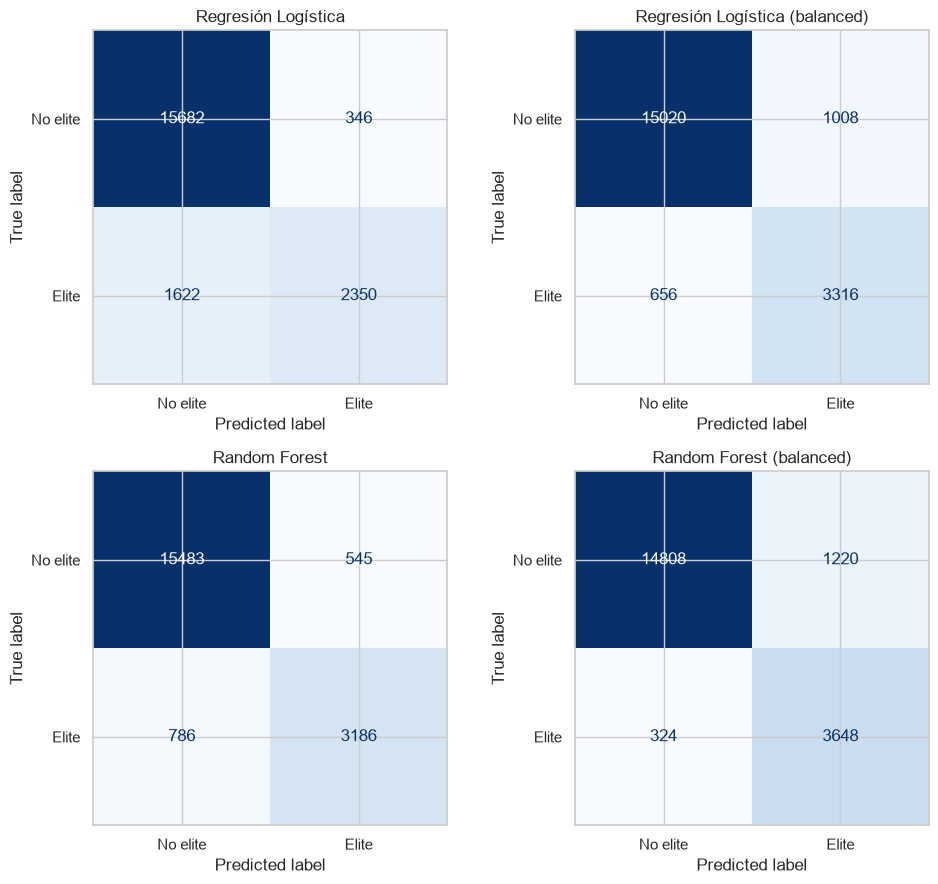

In [147]:
logistica_balanced = LogisticRegression(max_iter=2000, class_weight='balanced', **best_logistic_params)
logistica_balanced.fit(X_binclass_train_scaled, y_binclass_train)
y_pred_logistica_bal = logistica_balanced.predict(X_binclass_test_scaled)
y_score_logistica_bal = logistica_balanced.predict_proba(X_binclass_test_scaled)[:, 1]

rf_clf_balanced = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced', **best_rf_params)
rf_clf_balanced.fit(X_binclass_train, y_binclass_train)
y_pred_rf_bal = rf_clf_balanced.predict(X_binclass_test)
y_score_rf_bal = rf_clf_balanced.predict_proba(X_binclass_test)[:, 1]

balanced_results = {
    'Regresión Logística (balanced)': {
        'Exactitud': accuracy_score(y_binclass_test, y_pred_logistica_bal),
        'F1': f1_score(y_binclass_test, y_pred_logistica_bal),
        'Precisión': precision_score(y_binclass_test, y_pred_logistica_bal),
        'Recall': recall_score(y_binclass_test, y_pred_logistica_bal),
        'ROC-AUC': roc_auc_score(y_binclass_test, y_score_logistica_bal),
        'PR-AUC': average_precision_score(y_binclass_test, y_score_logistica_bal),
    },
    'Random Forest (balanced)': {
        'Exactitud': accuracy_score(y_binclass_test, y_pred_rf_bal),
        'F1': f1_score(y_binclass_test, y_pred_rf_bal),
        'Precisión': precision_score(y_binclass_test, y_pred_rf_bal),
        'Recall': recall_score(y_binclass_test, y_pred_rf_bal),
        'ROC-AUC': roc_auc_score(y_binclass_test, y_score_rf_bal),
        'PR-AUC': average_precision_score(y_binclass_test, y_score_rf_bal),
    },
}

comparacion_balanced = pd.DataFrame({
    'Regresión Logística': metrics_df_full.loc['Regresión Logística'],
    'Regresión Logística (balanced)': balanced_results['Regresión Logística (balanced)'],
    'Random Forest': metrics_df_full.loc['Random Forest'],
    'Random Forest (balanced)': balanced_results['Random Forest (balanced)'],
}).T

print("Tuneado vs. class_weight='balanced':")
display(comparacion_balanced.round(4))

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
pairs = [
    ('Regresión Logística', y_pred_logistica, axes[0, 0]),
    ('Regresión Logística (balanced)', y_pred_logistica_bal, axes[0, 1]),
    ('Random Forest', y_pred_rf, axes[1, 0]),
    ('Random Forest (balanced)', y_pred_rf_bal, axes[1, 1]),
]
for nombre, y_pred, ax in pairs:
    cm = confusion_matrix(y_binclass_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No elite', 'Elite']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
plt.tight_layout()
plt.show()


#### Interpretación

- Si `class_weight='balanced'` sube el Recall de la clase elite a costa de Precisión (más falsos positivos), conviene evaluarlo según el uso real: para "detectar candidatos a embajador de marca" suele preferirse más Recall.
- El PR-AUC es la métrica más confiable para comparar modelos bajo este desbalance (~80/20): a diferencia del ROC-AUC, no se infla por la gran cantidad de negativos verdaderos.
- El Dummy da el piso real de comparación: cualquier modelo entrenado debería superarlo claramente en F1/Recall/PR-AUC, no solo en Exactitud.

## Conclusión general

El trabajo de modelado quedó organizado en dos frentes:

1. Regresión
   - Regresión lineal como baseline
   - Random Forest como modelo no lineal más completo

2. Clasificación
   - Heurística como referencia básica
   - Regresión logística, SVM, árboles de decisión y random forest para comparar rendimiento
   - Evaluación adicional para clase minoritaria (sección 3): matriz de confusión, PR-AUC, baseline trivial (`DummyClassifier`) y una corrida con `class_weight='balanced'`

### Sobre la clasificación: lectura de los resultados finales

Los números de la sección 2 correspondían originalmente a un dataset con **data leakage** (`is_elite` había quedado como feature, siendo la misma señal que el target `elite_encoded`), lo que producía F1/ROC-AUC ≈ 1.0000 en todos los modelos entrenados. Tras excluir `is_elite` de las features, las métricas bajaron a valores realistas — comportamiento esperado y saludable ante un leak corregido.

Con el dataset ya limpio, ordenando por PR-AUC (la métrica más confiable bajo el desbalance ~80/20 de `elite_encoded`, ya que a diferencia de ROC-AUC no se infla por la gran cantidad de negativos verdaderos):

| Modelo | Exactitud | F1 | Precisión | Recall | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| Random Forest | 0.9334 | 0.8272 | 0.8539 | 0.8021 | 0.9771 | 0.9134 |
| Decision Tree | 0.9274 | 0.8112 | 0.8383 | 0.7858 | 0.9698 | 0.8807 |
| SVM | 0.9081 | 0.7299 | 0.8768 | 0.6251 | 0.9619 | 0.8626 |
| Regresión Logística | 0.9016 | 0.7049 | 0.8717 | 0.5916 | 0.9587 | 0.8483 |
| Heurística | 0.9124 | 0.7647 | 0.8201 | 0.7163 | 0.9038 | 0.7477 |
| Dummy (trivial) | 0.8014 | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.1986 |

Dos hallazgos relevantes:

- **La heurística supera en F1 a los modelos lineales tuneados** (0.7647 vs. 0.7049 de Regresión Logística y 0.7299 de SVM), pero pierde contra ellos en PR-AUC (0.7477 vs. 0.8483 y 0.8626). Esto indica que Regresión Logística y SVM sí separan mejor las clases en términos de ranking, pero con el umbral de decisión por defecto (0.5) son demasiado conservadores (Recall bajo). La heurística, al ser una regla de umbrales ("≥2 de 3"), se comporta más como un árbol de decisión superficial — por eso Decision Tree y Random Forest, que también particionan el espacio en umbrales, la superan cómodamente en ambas métricas.
- **`class_weight='balanced'`** sobre Regresión Logística y Random Forest (mismos hiperparámetros tuneados con Optuna) sube fuertemente el Recall (0.5916→0.8348 y 0.8021→0.9184 respectivamente) a costa de Precisión, con un PR-AUC casi sin cambios (0.8483→0.8598 y 0.9134→0.9126) — coherente con que el `class_weight` mueve el umbral de decisión pero no la capacidad de ranking del modelo.

**Recomendación**: para el objetivo de negocio planteado (detectar candidatos a embajador de marca antes de que se vuelvan populares), un falso negativo probablemente cuesta más que un falso positivo, por lo que conviene priorizar Recall. **Random Forest con `class_weight='balanced'`** ofrece el mejor balance: Recall alto (0.9184) sin resignar PR-AUC (0.9126) ni F1 (0.8253) respecto de su versión sin balancear.

La comparación general se debe interpretar con cuidado según el objetivo:
- si se busca interpretabilidad, la regresión lineal y los árboles son muy útiles
- si se prioriza rendimiento puro (PR-AUC/ROC-AUC), el random forest suele ofrecer mejores resultados
- si se prioriza detectar la mayor cantidad posible de casos elite reales, el random forest con `class_weight='balanced'` es la opción más razonable
- si se busca equilibrio entre simplicidad y capacidad predictiva, la regresión logística y la heurística son opciones razonables, con la salvedad de que su F1 por defecto podría mejorar si se calibra el umbral de decisión (no explorado en esta notebook)

Este esquema permite mantener todo el análisis ordenado por modelo, con sus métricas y su interpretación en un único lugar.